# NB05 — Model Diagnostics

## Block 1: Reconciliation and Prediction Geometry

**Scope.** Four configurations persisted by NB04 (Sessão B + C, 28–29/abr/2026): `C8` (XGBoost, crude-only, N=116/29 folds), `C1` (XGBoost, mixed types, N=176/44 folds), `C7` (DummyRegressor mean baseline, C8 scope), `C7_mixed` (DummyRegressor mean baseline, C1 scope). Block 1 establishes (1) cross-config reconciliation, (2) discovery of C62ALL pivot dropouts plus composition characterization of C1\\C8 extras, (3) prediction geometry per stage, (4) confusion matrix delta C1 − C8, (5) outlier oil 123 case study, (6) per-config response of the 5 W0→W2 overshoot oils.

**Hypothesis mapping (cells ↔ hypotheses):**

| Cell | Covered in this cell | Deferred to Block 2 |
|---|---|---|
| 1 | Precondition for all paired analyses (oil_id alignment cross-config) | — |
| 2 | (iv) scope expansion — names the 3 non-crude oils dropped from C62ALL pivot, paralleling the 14 partial-stage crudes from D-DATA-SCOPE-NB04. Composition characterization of C1\\C8 extras seeds Cell 6 narrative. | Vintage covariate test on the full 17-oil dropped set (14 crude + 3 non-crude); logistic regression for protocol-drift mechanism agnostic to oil_type |
| 3 | Preview of (ii)+(v) joint signature via prediction shape per stage | Formal regression-to-mean vs boundary-effect decomposition (ii) |
| 4 | (ii) off-by-N pattern + (v) MAE vs C7 baseline magnitude | Statistical anchor for sample-size sensitivity (v) |
| 5 | (iii) outlier oil 123 stage-localized residual decomposition | SHAP attribution for oil 123 failure modes |
| 6 | (i) sub i-a (diversity helps) vs sub i-b (similarity helps) preliminary signature, anchored by composition of C1\\C8 neighbors quantified in Cell 2 | API gravity stratification, geography vs peer-availability disentangling, logistic regression formal test |
| — | — | (iv) vintage × W0_overshoot — requires temporal covariate Block 1 does not touch |

**Out of scope (deferred to Block 2 in next session).** API gravity stratification, geography vs peer-availability disentangling, formal sample-size sensitivity test, regression-to-mean vs boundary-effect formal decomposition, SHAP residual attribution, vintage covariate analysis on dropped oils set (Cell 2 only names the oils, does not test temporal pattern).

**Cross-references.** D-DATA-SCOPE-NB04 (29 complete crudes + 14 partial + 1 absent → C8 N=116). D-PREREQUISITE-CLOSED (Sessão C strict gate closure, MAE(C1)/MAE(C7_mixed) = 0.486 < 0.80). D-HYPOTHESIS-V (sample-size sensitivity registered descriptively). HIPOTESES_v1_0.md §i-revisada / §ii / §iii / §iv / §v.

**Halt-on-anomaly.** Cell 1 enforces 9 invariants. If any assertion fails the notebook halts; diagnostic context is already visible in the prints above the assertion block, so the failure point is locatable without re-execution. Re-running Cell 1 after a regression upstream in NB04 is the correct next step, not patching Block 1.

### Block 2 — Pre-registration (Sessão H2)

*Locked Sessão H2 (04/mai/2026); applied Sessão I. Per GUARDRAILS §18 (PRE-COMMITMENT DISCIPLINE FOR ANALYSIS DESIGN): scaffolding-level commitments below are §18.5 design choices, not §18.2 hypothesis-content `D-*` decisions. Cell 1 pre-reg block follows §18.2 (a)/(b) discipline.*

#### Scaffolding decisions (A–G)

**(A) Sequencing.**
1. **#2 SHAP attribution per stage** — AC25 mechanism (d) test. Primary cell.
2. **#5 Peer ranking, Prudhoe Bay (oil 222)** — convergent test for D-NB05-HEAVY-BITUMEN-CONFOUNDING (2/2 evidence target).

**(B) Cell budget.** 12–13 cells matching Block 1 cadence. Split point: Block 2a / 2b at end-of-#5 if narrative overruns.

#### Cell 1 [PRE-REG, Sessão H2]

**Target.** SHAP attribution per stage for **all 29 C8 oils** (full 4-stage panel; model = NB04 C8 final). AC25 (oil 123, Alaminos Canyon Block 25) is one point in the resulting 29-oil distribution of mean cross-stage Jaccard.

**Hypothesis tested.** Mechanism (d) from Block 1 Cell 5 — *"AC25 lacks learned weathering signature in feature space"* (D-NB05-MECHANISM-D-AC25-30ABR).

**Empirical signatures.**
- If (d) true: AC25 mean Jaccard at high tail of the 29-oil distribution (e.g., percentile ≥ 90).
- If (d) false: AC25 within body (percentile [10, 90]).

**Decision rule.** Percentile-based, evaluated post-observation. **Specific tail and body thresholds pre-committed at cell-gate after distribution shape is visible — but BEFORE evaluating where AC25 lands.** Per §18.4: no pre-committed numerical thresholds at scaffold time. Per §18 first-test discipline: document the commit-vs-AC25-known timing in cell markdown as discipline-check passed/failed.

**Sensitivity panels.** Top-k SHAP feature sets (k = 5, 10, 20) as in-cell side-by-side panels, not separate cells.

**§18.2 cell-gate granularity preserved.** Cells 2–12 design happens at their own gates, informed by results — not pre-specified at scaffold time.

#### Cell 1 [POST-RUN, Sessão I+]

*To be filled after Cell 1 executes (§18.2). Will record: AC25 percentile observed, pre-committed thresholds (with order-of-commit timestamp), discipline-check outcome, codification candidate (D-NB05-AC25-NO-WEATHERING-SIGNATURE if supported; mechanism re-opening / new candidate (e) if refuted).*


In [30]:
# Cell 1 — Cross-config oil inventory reconciliation.
# Read-only sanity over NB04-persisted state. No mutations to weathering.db.
# Pattern: load -> display -> assert. Display before asserts so halt-on-anomaly
# delivers diagnostic context in stdout before the AssertionError fires.

import sys
sys.path.insert(0, '.')
from utils import get_conn

import pandas as pd

# --- 1. LOAD ----------------------------------------------------------------
# Schema (a) confirmed: looo_predictions has `config_name` discriminator.
# PK = (config_name, oil_id, stage_code). Source: utils.run_looo persistence
# (lines 770-780) and NB04 cell 'CREATE TABLE looo_predictions' header.

with get_conn() as conn:
    df_c8  = pd.read_sql("SELECT DISTINCT oil_id FROM looo_predictions WHERE config_name = 'C8'",       conn)
    df_c1  = pd.read_sql("SELECT DISTINCT oil_id FROM looo_predictions WHERE config_name = 'C1'",       conn)
    df_c7  = pd.read_sql("SELECT DISTINCT oil_id FROM looo_predictions WHERE config_name = 'C7'",       conn)
    df_c7m = pd.read_sql("SELECT DISTINCT oil_id FROM looo_predictions WHERE config_name = 'C7_mixed'", conn)
    oil_types = pd.read_sql(
        "SELECT oil_id, oil_name, oil_type FROM oils WHERE include_in_analysis = 1",
        conn,
    )

n_c8, n_c1, n_c7, n_c7m = (
    df_c8.oil_id.nunique(),
    df_c1.oil_id.nunique(),
    df_c7.oil_id.nunique(),
    df_c7m.oil_id.nunique(),
)
c8_set, c1_set = set(df_c8.oil_id), set(df_c1.oil_id)
c7_set, c7m_set = set(df_c7.oil_id), set(df_c7m.oil_id)

inventory = oil_types.copy()
inventory['in_C8'] = inventory.oil_id.isin(c8_set)
inventory['in_C1'] = inventory.oil_id.isin(c1_set)
inventory['scope'] = inventory.apply(
    lambda r: 'C8 ∩ C1' if r.in_C8 and r.in_C1
              else ('C1 only' if r.in_C1
              else 'neither'),
    axis=1,
)

# --- 2. DISPLAY (diagnostic context BEFORE asserts) -------------------------

print(f"Counts: C8={n_c8}, C1={n_c1}, C7={n_c7}, C7_mixed={n_c7m}")
print(f"|C8 ∩ C1| = {len(c8_set & c1_set)}, "
      f"|C1 \\ C8| = {len(c1_set - c8_set)}, "
      f"|C8 \\ C1| = {len(c8_set - c1_set)}")
print()
print("Scope distribution:")
print(inventory.scope.value_counts())
print()
print("Distribution of oil_type within each scope:")
print(pd.crosstab(inventory.scope, inventory.oil_type, margins=True))
print()

# Scope drift: any NB04-persisted oil whose include_in_analysis flag has since
# flipped to 0. Computed over the full 4-set union to decouple from the subset
# invariant below (defense-in-depth: if subset is violated AND drift exists in
# the violator oil, the narrower union c1_set | c7m_set would miss it).
persisted_ids = c8_set | c1_set | c7_set | c7m_set
included_ids = set(oil_types.oil_id)
drift = persisted_ids - included_ids
if drift:
    print(f"⚠ Scope drift detected: {len(drift)} NB04-persisted oils now have include_in_analysis=0")
    print(f"   oil_ids: {sorted(drift)}")
else:
    print("✓ No scope drift — all NB04-persisted oils still flagged include_in_analysis=1")

extras = c1_set - c8_set
extras_df = oil_types[oil_types.oil_id.isin(extras)].sort_values('oil_id')
print()
print(f"C1 \\ C8 extras ({len(extras)} oils — must all be non-crude):")
print(extras_df[['oil_id', 'oil_name', 'oil_type']].to_string(index=False))
print()

# --- 3. ASSERTS (halt-on-anomaly; 9 invariants) -----------------------------

assert n_c8  == 29, f"C8 expected 29 oils (D-DATA-SCOPE-NB04), got {n_c8}"
assert n_c1  == 44, f"C1 expected 44 oils (D-DATA-SCOPE-NB04), got {n_c1}"
assert n_c7  == 29, f"C7 expected 29 oils (paired with C8), got {n_c7}"
assert n_c7m == 44, f"C7_mixed expected 44 oils (paired with C1), got {n_c7m}"

assert c8_set.issubset(c1_set), \
    f"C8 must be subset of C1. Diff (C8 \\ C1): {c8_set - c1_set}"

assert c7_set  == c8_set, f"C7 oils must match C8 oils. Symmetric diff: {c7_set ^ c8_set}"
assert c7m_set == c1_set, f"C7_mixed oils must match C1 oils. Symmetric diff: {c7m_set ^ c1_set}"

assert not drift, \
    f"Scope drift: NB04-persisted oils now flagged include_in_analysis=0: {sorted(drift)}"

extras_types = extras_df.oil_type.value_counts()
assert (extras_types.index != 'crude').all(), \
    f"All C1 \\ C8 extras must be non-crude. Found types: {extras_types.to_dict()}"

print("✓ All 9 Cell 1 invariants passed. Block 1 reconciliation complete; safe to proceed to Cells 2–5 in next session.")


Counts: C8=29, C1=44, C7=29, C7_mixed=44
|C8 ∩ C1| = 29, |C1 \ C8| = 15, |C8 \ C1| = 0

Scope distribution:
scope
C8 ∩ C1    29
neither    18
C1 only    15
Name: count, dtype: int64

Distribution of oil_type within each scope:
oil_type  bitumen_blend  crude  refined  synthetic  All
scope                                                  
C1 only               7      0        6          2   15
C8 ∩ C1               0     29        0          0   29
neither               2     15        1          0   18
All                   9     44        7          2   62

✓ No scope drift — all NB04-persisted oils still flagged include_in_analysis=1

C1 \ C8 extras (15 oils — must all be non-crude):
 oil_id                          oil_name      oil_type
    122          Access West Blend Winter bitumen_blend
    162     Cold Lake Blend Summer [2014] bitumen_blend
    163     Cold Lake Blend Winter [2013] bitumen_blend
    164     Cold Lake Blend Winter [2015] bitumen_blend
    165     Cold Lake Blen

## Cell 2 — Discovery: dropped C62ALL oils + composition of C1\\C8 extras

Two side-discoveries from Cell 1 reconciliation, isolated here to keep their indirect provenance (set complement) distinct from Cell 1's direct invariant validation.

**Discovery 1 (F-NB05-S1).** The "neither" scope (18 oils persisted in zero configs) contains 15 crude (the 14 partial-stage + 1 absent oil 125 ANS 2010 from D-DATA-SCOPE-NB04) plus **3 non-crude oils not previously characterized**. These 3 oils failed `pivot_table(dropna=True)` in C62ALL by the same mechanism that excluded the 14 crudes from C45CRUDE. Names them for hypothesis (iv) cross-type vintage analysis in Block 2. Paper B SI Methods needs the full 17-oil dropped set, not 14.

**Discovery 2 (F-NB05-S2).** The 15 C1\\C8 extras decompose into compositional neighborhoods that anchor hypothesis (i) sub-claims in Cell 6. Sketch from Sessão D identified 3 neighborhoods (Cold Lake heavy / Marine Diesel light / Sweet Synthetic intermediate) by oil_name pattern; Cell 2 confirms quantitatively via API gravity, density, pour point at W0. The Sweet Synthetic neighborhood placement (light vs intermediate) materially affects Cell 6's sub i-a / sub i-b mapping.

Output: two tables — (1) 3 non-crude dropped oils with names + types; (2) 21 oils (15 C1\\C8 extras + 5 W0→W2 overshoot + oil 123 robust outlier) with W0 composition columns + bucket assignment.

This cell is read-only; no mutations to weathering.db.


In [31]:
# Cell 2 — Block 1 discovery: dropped C62ALL oils + composition characterization.
# Read-only (no mutations to weathering.db). Two queries:
#   (1) Names the 3 non-crude dropped oils (paralleling the 14 crude
#       from D-DATA-SCOPE-NB04, F-NB05-S1).
#   (2) W0 composition (API, density, pour point) for 21 oils relevant
#       to Cells 3-6 narratives (F-NB05-S2 quantitative anchor).

import sys
sys.path.insert(0, '.')
from utils import get_conn

import pandas as pd

# --- Pre-step: discover property_name canonical strings + temperature_c
#               + condition distribution at W0. Density may be measured
#               at multiple temperatures and/or conditions; API and pour
#               are typically single-valued per (oil, stage). ---

with get_conn() as conn:
    prop_discovery = pd.read_sql("""
        SELECT
            property_name,
            COUNT(*)                              AS n_rows,
            COUNT(DISTINCT temperature_c)         AS n_temps,
            COUNT(DISTINCT condition)             AS n_conditions,
            GROUP_CONCAT(DISTINCT temperature_c)  AS temps_present,
            GROUP_CONCAT(DISTINCT condition)      AS conditions_present
          FROM sample_properties
         WHERE (property_name LIKE '%api%'
             OR property_name LIKE '%densit%'
             OR property_name LIKE '%pour%')
           AND stage_code = 'W0'
         GROUP BY property_name
         ORDER BY property_name
    """, conn)

print("Property name + temperature_c + condition distribution at W0:")
print(prop_discovery.to_string(index=False))
print()

api_name     = 'api_gravity'
density_name = 'density'
pour_name    = 'pour_point'

available = set(prop_discovery.property_name)
for name, label in [(api_name, 'API'), (density_name, 'density'), (pour_name, 'pour point')]:
    if name not in available:
        print(f"⚠ '{name}' ({label}) not in available property names. Available: {available}")
print()

# --- Density temperature filter: ASTM/ECCC convention is 15 °C. ---
#     Density condition filter: 'standard' typical for ECCC W0.
density_row = prop_discovery[prop_discovery.property_name == density_name]
if len(density_row) == 0:
    print(f"⚠ No '{density_name}' rows at W0 — Discovery 2 will return NULL density_w0.")
    density_temp_filter = ''
    density_cond_filter = ''
else:
    n_density_temps = int(density_row.iloc[0].n_temps)
    n_density_conds = int(density_row.iloc[0].n_conditions)
    temps_str = density_row.iloc[0].temps_present
    conds_str = density_row.iloc[0].conditions_present

    # Temperature dimension
    if n_density_temps <= 1:
        print(f"✓ Density measured at single temperature — no temperature filter needed.")
        density_temp_filter = ''
    else:
        print(f"⚠ Density measured at {n_density_temps} temperatures: {temps_str}")
        available_temps = [float(t) for t in str(temps_str).split(',') if t.strip()]
        if 15.0 in available_temps:
            density_temp_filter = ' AND sp.temperature_c = 15.0'
            print(f"→ Filtering density to temperature_c = 15.0 °C (ASTM/ECCC convention).")
        else:
            candidates = sorted(available_temps, key=lambda t: (abs(t - 15.0), t))
            chosen_temp = candidates[0]
            density_temp_filter = f' AND sp.temperature_c = {chosen_temp}'
            print(f"⚠ 15.0 °C not present; falling back to {chosen_temp} °C (closest available).")
            print(f"   Cell 6 narrative MUST cite this temperature explicitly when reporting density.")

    # Condition dimension
    if n_density_conds <= 1:
        print(f"✓ Density measured at single condition — no condition filter needed.")
        density_cond_filter = ''
    else:
        print(f"⚠ Density measured at {n_density_conds} conditions: {conds_str}")
        available_conds = [c.strip() for c in str(conds_str).split(',') if c.strip()]
        if 'standard' in available_conds:
            density_cond_filter = " AND sp.condition = 'standard'"
            print(f"→ Filtering density to condition = 'standard' (ECCC W0 convention).")
        else:
            chosen_cond = available_conds[0]
            density_cond_filter = f" AND sp.condition = '{chosen_cond}'"
            print(f"⚠ 'standard' condition not present; falling back to '{chosen_cond}'.")
            print(f"   Cell 6 narrative MUST cite this condition explicitly when reporting density.")
print()

# --- Query 1: Name the 3 non-crude dropped oils (Discovery 1) ---
with get_conn() as conn:
    dropped_non_crude = pd.read_sql("""
        SELECT o.oil_id, o.oil_name, o.oil_type
          FROM oils o
         WHERE o.include_in_analysis = 1
           AND o.oil_type != 'crude'
           AND o.oil_id NOT IN (
               SELECT DISTINCT oil_id FROM looo_predictions WHERE config_name = 'C1'
           )
         ORDER BY o.oil_type, o.oil_id
    """, conn)

print("=" * 70)
print("Discovery 1: Non-crude oils dropped from C62ALL pivot")
print("=" * 70)
print(f"Count: {len(dropped_non_crude)}")
print(dropped_non_crude.to_string(index=False))
print()

n_dropped_nc = len(dropped_non_crude)
type_counts = dropped_non_crude.oil_type.value_counts().to_dict()
print(f"Type distribution: {type_counts}")
assert n_dropped_nc == 3, \
    f"Expected 3 non-crude dropped (Cell 1 set arithmetic implied 2 bb + 1 refined). Got {n_dropped_nc}."
assert type_counts.get('bitumen_blend', 0) == 2, \
    f"Expected 2 bitumen_blend dropped. Got {type_counts.get('bitumen_blend', 0)}."
assert type_counts.get('refined', 0) == 1, \
    f"Expected 1 refined dropped. Got {type_counts.get('refined', 0)}."
print()
print("✓ Discovery 1 cardinality matches Cell 1 set arithmetic implication.")
print()

# --- Query 2: W0 composition for 21 narrative-relevant oils ---
oil_buckets = {
    # 7 heavy/dilbit (C1 \ C8)
    122: 'C1_extras_heavy',  162: 'C1_extras_heavy',  163: 'C1_extras_heavy',
    164: 'C1_extras_heavy',  165: 'C1_extras_heavy',  166: 'C1_extras_heavy',
    231: 'C1_extras_heavy',
    # 6 Marine Diesel (C1 \ C8)
    200: 'C1_extras_marine_diesel', 201: 'C1_extras_marine_diesel',
    202: 'C1_extras_marine_diesel', 203: 'C1_extras_marine_diesel',
    204: 'C1_extras_marine_diesel', 205: 'C1_extras_marine_diesel',
    # 2 Sweet Synthetic Crude (C1 \ C8)
    228: 'C1_extras_synthetic', 229: 'C1_extras_synthetic',
    # 5 W0 → W2 overshoot
    137: 'W0_overshoot_5', 184: 'W0_overshoot_5', 189: 'W0_overshoot_5',
    212: 'W0_overshoot_5', 222: 'W0_overshoot_5',
    # 1 robust outlier
    123: 'robust_outlier',
}

oil_ids_str = ','.join(str(i) for i in oil_buckets.keys())
density_filter = density_temp_filter + density_cond_filter

with get_conn() as conn:
    composition = pd.read_sql(f"""
        SELECT
            o.oil_id,
            o.oil_name,
            o.oil_type,
            MAX(CASE WHEN sp.property_name = '{api_name}'                       THEN sp.value END) AS api_w0,
            MAX(CASE WHEN sp.property_name = '{density_name}'{density_filter}   THEN sp.value END) AS density_w0,
            MAX(CASE WHEN sp.property_name = '{pour_name}'                      THEN sp.value END) AS pour_w0
          FROM oils o
          LEFT JOIN sample_properties sp
               ON sp.oil_id = o.oil_id AND sp.stage_code = 'W0'
         WHERE o.oil_id IN ({oil_ids_str})
         GROUP BY o.oil_id, o.oil_name, o.oil_type
         ORDER BY o.oil_id
    """, conn)

composition['bucket'] = composition.oil_id.map(oil_buckets)
composition = composition.sort_values(
    by=['bucket', 'api_w0'],
    ascending=[True, False],
    na_position='last',
).reset_index(drop=True)

print("=" * 70)
print("Discovery 2: W0 composition of 21 narrative-relevant oils")
print("=" * 70)
print(f"Count: {len(composition)}")
print(composition.to_string(index=False))
print()

assert len(composition) == 21, f"Expected 21 oils, got {len(composition)}."

bucket_counts = composition.bucket.value_counts().to_dict()
print(f"Bucket distribution: {bucket_counts}")
expected_buckets = {
    'C1_extras_heavy': 7,
    'C1_extras_marine_diesel': 6,
    'C1_extras_synthetic': 2,
    'W0_overshoot_5': 5,
    'robust_outlier': 1,
}
for bucket, expected_n in expected_buckets.items():
    actual_n = bucket_counts.get(bucket, 0)
    assert actual_n == expected_n, \
        f"Bucket {bucket}: expected {expected_n}, got {actual_n}."
print()
print("✓ Discovery 2 cardinality matches expected bucket distribution.")
print()

# --- Per-bucket composition summary (median, range) — seeds Cell 6 narrative ---
print("=" * 70)
print("Per-bucket composition summary (median, [min, max]) for Cell 6 anchoring")
print("=" * 70)
summary = composition.groupby('bucket').agg(
    n=('oil_id', 'size'),
    api_median=('api_w0', 'median'),
    api_min=('api_w0', 'min'),
    api_max=('api_w0', 'max'),
    density_median=('density_w0', 'median'),
    pour_median=('pour_w0', 'median'),
).round(2)
print(summary.to_string())
print()

# --- Sweet Synthetic placement verdict (NaN-safe via pd.notna) ---
synth_api  = composition[composition.bucket == 'C1_extras_synthetic'].api_w0.median()
diesel_api = composition[composition.bucket == 'C1_extras_marine_diesel'].api_w0.median()
heavy_api  = composition[composition.bucket == 'C1_extras_heavy'].api_w0.median()
print(f"Sweet Synthetic median API: {synth_api}")
print(f"Marine Diesel median API:   {diesel_api}")
print(f"Cold Lake heavy median API: {heavy_api}")
if pd.notna(synth_api) and pd.notna(diesel_api) and pd.notna(heavy_api):
    midpoint = (diesel_api + heavy_api) / 2
    if synth_api > midpoint:
        print(f"→ Synthetic placement: closer to LIGHT (Marine Diesel side; midpoint={midpoint:.2f})")
        print(f"  → F-NB05-S2 refinement: 2 light neighborhoods (synth + diesel) + 1 heavy")
    else:
        print(f"→ Synthetic placement: closer to HEAVY/INTERMEDIATE (midpoint={midpoint:.2f})")
        print(f"  → F-NB05-S2 refinement: synthetic preserves intermediate role")
else:
    print(f"⚠ Sweet Synthetic placement verdict UNKNOWN — at least one bucket median is NaN.")
    print(f"   synth NaN={pd.isna(synth_api)}, diesel NaN={pd.isna(diesel_api)}, heavy NaN={pd.isna(heavy_api)}")
    print(f"   F-NB05-S2 refinement deferred until source NaN cause investigated.")
print()

print("✓ Cell 2 complete. Discoveries 1 + 2 ready for handoff to Cells 3-6 planning.")


Property name + temperature_c + condition distribution at W0:
property_name  n_rows  n_temps  n_conditions temps_present conditions_present
  api_gravity      96        0             0          None               None
      density     213        3             0  15.0,0.0,5.0               None
   pour_point      75        0             0          None               None


⚠ Density measured at 3 temperatures: 15.0,0.0,5.0
→ Filtering density to temperature_c = 15.0 °C (ASTM/ECCC convention).
✓ Density measured at single condition — no condition filter needed.

Discovery 1: Non-crude oils dropped from C62ALL pivot
Count: 3
 oil_id                     oil_name      oil_type
    129 Alberta Sweet Mixed Blend #4 bitumen_blend
    130 Alberta Sweet Mixed Blend #5 bitumen_blend
    173                Diesel [2002]       refined

Type distribution: {'bitumen_blend': 2, 'refined': 1}

✓ Discovery 1 cardinality matches Cell 1 set arithmetic implication.

Discovery 2: W0 composition of 21 narra

## Cell 3 — Prediction shape per config × stage (grid 2×4)

Documents how each ML config (C8, C1) distributes predictions across the 4 ordinal stages, before any error analysis. Histograms reveal **shape** — saturation at boundaries, regression-to-mean in interior stages, bimodality — that aggregate MAE conceals.

**Visual hypothesis preview (formal tests deferred to Block 2):**

- **Hypothesis (ii) regression-to-mean vs boundary-effect.** If W1/W2 panels cluster around 1.5 (range mean), evidence for regression-to-mean. If they spread [0.5, 2.5] centered at 1 and 2, evidence for boundary-effect (composition signal preserved).
- **Hypothesis (v) sample-size sensitivity.** If C1 (N=176) shows W1/W2 panels with more separated shape than C8 (N=116), preliminary evidence that increasing N addresses interior-stage discriminability.
- **DummyRegressor reference line (x=1.5)** anchored in each panel: trivial baseline predicts constant mean of LOOO uniform train labels. Distance between cluster center and 1.5 line = "how much each model beats the no-signal floor in this stage". W2 panel near-overlap = (v) signature.

This cell is read-only; no mutations to weathering.db. Block 1 hypothesis mapping in Cell 0 covers (ii)+(v) preview.


In [32]:
# Cell 3 — Prediction shape per config × stage (grid 2×4).
# Read-only over NB04 persisted predictions. No mutations.

import sys
sys.path.insert(0, '.')
from utils import get_conn, DB_PATH, FIG_ROOT, PROJECT_ROOT, setup_figure_style

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FIG_DIR = FIG_ROOT / 'nb05'
FIG_DIR.mkdir(parents=True, exist_ok=True)

setup_figure_style()

# --- 1. LOAD predictions for ML configs (C8, C1) ---
with get_conn() as conn:
    df_preds = pd.read_sql("""
        SELECT config_name, oil_id, stage_code, y_true, y_pred
          FROM looo_predictions
         WHERE config_name IN ('C8', 'C1')
         ORDER BY config_name, oil_id, stage_code
    """, conn)

n_c8 = (df_preds.config_name == 'C8').sum()
n_c1 = (df_preds.config_name == 'C1').sum()
print(f"Loaded {n_c8} C8 predictions, {n_c1} C1 predictions")
assert n_c8 == 116, f"C8 expected 116 prediction rows, got {n_c8}"
assert n_c1 == 176, f"C1 expected 176 prediction rows, got {n_c1}"

for cfg in ['C8', 'C1']:
    sub = df_preds[df_preds.config_name == cfg]
    print(f"  {cfg}: y_pred range [{sub.y_pred.min():.3f}, {sub.y_pred.max():.3f}], "
          f"median {sub.y_pred.median():.3f}")
print()

# --- 2. BUILD 2×4 grid (rows = config, cols = stage) ---
configs = ['C8', 'C1']
stages = ['W0', 'W1', 'W2', 'W3']
truth_per_stage = {'W0': 0, 'W1': 1, 'W2': 2, 'W3': 3}

xmin, xmax = -0.5, 3.5
bin_edges = np.arange(xmin, xmax + 0.2, 0.2)

fig, axes = plt.subplots(
    nrows=2, ncols=4,
    figsize=(14, 6),
    sharex=True,
    sharey=False,
)

for i, cfg in enumerate(configs):
    for j, stage in enumerate(stages):
        ax = axes[i, j]
        sub = df_preds[(df_preds.config_name == cfg) & (df_preds.stage_code == stage)]
        n = len(sub)
        med = sub.y_pred.median()
        q25 = sub.y_pred.quantile(0.25)
        q75 = sub.y_pred.quantile(0.75)

        ax.hist(sub.y_pred, bins=bin_edges, color='steelblue',
                edgecolor='white', linewidth=0.5, alpha=0.85)

        truth = truth_per_stage[stage]
        ax.axvline(truth, color='black', linestyle='-', linewidth=1.0, alpha=0.7,
                   label='truth (per panel)' if (i == 0 and j == 0) else None)

        ax.axvline(1.5, color='crimson', linestyle='--', linewidth=1.0, alpha=0.7,
                   label='DummyRegressor (C7)' if (i == 0 and j == 0) else None)

        ax.text(0.97, 0.95,
                f"n={n}\nmed={med:.2f}\nIQR=[{q25:.2f}, {q75:.2f}]",
                transform=ax.transAxes,
                ha='right', va='top',
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='lightgray', alpha=0.85))

        if i == 0:
            ax.set_title(stage, fontsize=11, fontweight='bold')
        if j == 0:
            ax.set_ylabel(f'{cfg}\ncount', fontsize=10)
        else:
            ax.set_ylabel('')

        if i == 1:
            ax.set_xlabel('predicted weathering stage', fontsize=9)

        ax.set_xlim(xmin, xmax)

axes[0, 0].legend(loc='upper left', fontsize=8, framealpha=0.85)

plt.suptitle(
    f'Prediction shape per config × stage (n_C8={n_c8}, n_C1={n_c1})',
    fontsize=12, y=1.00,
)
# constrained_layout handles spacing (set by setup_figure_style); tight_layout
# would conflict with the engine and is unnecessary.

out_path = FIG_DIR / 'nb05_cell3_prediction_shape_grid.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f"✓ Figure saved: {out_path}")
plt.close()

print()
print("✓ Cell 3 complete. Shape geometry documented for Cells 4-6 narrative.")


Loaded 116 C8 predictions, 176 C1 predictions
  C8: y_pred range [-0.034, 3.080], median 1.409
  C1: y_pred range [-0.042, 3.091], median 1.486

✓ Figure saved: C:\Users\leogr\Documents\Data Science\TCC\figures\nb05\nb05_cell3_prediction_shape_grid.png

✓ Cell 3 complete. Shape geometry documented for Cells 4-6 narrative.


## Cell 4 — Confusion matrix delta C1 − C8

Decomposes aggregate "MAE difference" between C1 (MAE=0.486) and C8 (MAE=0.631) into **structured error pattern by stage**. Sessão B reported C8 confusion matrix with W3 best (69% exact-match), W0 with 5/29 jump-+2 errors to W2, W2 with 16/29 off-by-one errors to W1. Cell 4 reproduces for C1 and computes the **delta heatmap** — which errors C1 corrects, which persist cross-config.

**Geochemistry of the delta:**

- **Positive diagonal delta (C1 has more exact-matches).** C1 corrects an error pattern.
- **Negative off-diagonal delta on the (W2, W1) cell.** C1 corrects the W2 attractor-middle pattern specifically — evidence for hypothesis (v) sample-size addresses interior boundary effect.
- **W0 jump-+2 unchanged or worse in C1.** Evidence that W0 atypical-crude pathology is mechanistically distinct from W1/W2 boundary pathology — connects to hypothesis (i) sub-claims (Cell 6 territory), not (ii)/(v).

**Forensic implication of error direction (not magnitude).** Stage ordinal weathered has physical geometry, not arbitrary ordinal. W1→W2 represents continuous evaporation 25%→50% transition; off-by-one is quantitatively imprecise but qualitatively correct. W0→W2 jump = fresh oil identified as medium-weathered — categorically catastrophic forensic error. Magnitude is not the metric; direction is.

**Rounding convention.** Continuous predictions discretized via `np.clip(np.round(x).astype(int), 0, 3)`. NumPy `round` is banker's (round-half-to-even); P[exact half] ≈ 0 for non-degenerate predictions. `clip` handles boundary overflow (Sessão B reported C8 max=3.080).

This cell is read-only; no mutations to weathering.db.


In [33]:
# Cell 4 — Confusion matrix delta C1 − C8.
# Read-only. Persists JSON summary to docs/reports/nb05/.

# Idempotent FIG_DIR redefine — supports stand-alone execution
# of Cell 4 without Cell 3 in kernel session. Same convention
# as NB02/NB04 (per-NB FIG_DIR derived from FIG_ROOT).
from utils import FIG_ROOT, PROJECT_ROOT
FIG_DIR = FIG_ROOT / 'nb05'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Reuses df_preds loaded in Cell 3. If Cell 3 not executed in
# same kernel session, re-load:
if 'df_preds' not in dir():
    with get_conn() as conn:
        df_preds = pd.read_sql("""
            SELECT config_name, oil_id, stage_code, y_true, y_pred
              FROM looo_predictions
             WHERE config_name IN ('C8', 'C1')
        """, conn)
    print("Re-loaded df_preds (Cell 3 not in kernel session).")

# --- 1. ROUND + CLIP predictions to {0, 1, 2, 3} ---
df_preds = df_preds.copy()
df_preds['y_pred_int'] = np.clip(np.round(df_preds.y_pred).astype(int), 0, 3)
df_preds['y_true_int'] = df_preds.y_true.astype(int)

assert df_preds.y_true_int.between(0, 3).all(), \
    f"y_true contains values outside [0, 3]: {df_preds.y_true_int.unique()}"

overflow_low  = (df_preds.y_pred < 0).sum()
overflow_high = (df_preds.y_pred > 3).sum()
print(f"Rounding overflow: {overflow_low} predictions < 0, {overflow_high} predictions > 3")
print(f"  (Both clipped to [0, 3]. Sessão B reported C8 range [-0.034, 3.080].)")
print()

# --- 2. BUILD confusion matrices C8 + C1 ---
def build_confusion(df_sub):
    cm = pd.crosstab(
        df_sub.y_true_int, df_sub.y_pred_int,
        rownames=['truth'], colnames=['predicted'],
        dropna=False,
    )
    cm = cm.reindex(index=[0, 1, 2, 3], columns=[0, 1, 2, 3], fill_value=0)
    return cm

cm_c8 = build_confusion(df_preds[df_preds.config_name == 'C8'])
cm_c1 = build_confusion(df_preds[df_preds.config_name == 'C1'])

row_totals_c8 = cm_c8.sum(axis=1)
row_totals_c1 = cm_c1.sum(axis=1)

cm_c8_pct = cm_c8.div(row_totals_c8, axis=0) * 100
cm_c1_pct = cm_c1.div(row_totals_c1, axis=0) * 100
cm_delta_pct = cm_c1_pct - cm_c8_pct

print("=" * 70)
print("C8 confusion matrix (counts):")
print(cm_c8)
print()
print("C8 row-normalized %:")
print(cm_c8_pct.round(1))
print()
print("=" * 70)
print("C1 confusion matrix (counts):")
print(cm_c1)
print()
print("C1 row-normalized %:")
print(cm_c1_pct.round(1))
print()
print("=" * 70)
print("Delta C1 − C8 (percentage points; positive = C1 cell higher):")
print(cm_delta_pct.round(1))
print()

# --- 3. EXACT-MATCH RATE per stage (diagonal cells) ---
exact_c8 = pd.Series(np.diag(cm_c8_pct), index=[0, 1, 2, 3], name='C8_exact_pct')
exact_c1 = pd.Series(np.diag(cm_c1_pct), index=[0, 1, 2, 3], name='C1_exact_pct')
exact_summary = pd.concat([exact_c8, exact_c1], axis=1)
exact_summary['delta'] = exact_summary.C1_exact_pct - exact_summary.C8_exact_pct
print("Exact-match rate per stage:")
print(exact_summary.round(1))
print()
print("(Sessão B reported C8: W3 best 69% exact-match; W2 had 16/29 off-by-one to W1)")
print()

# --- 4. PLOT 3-panel figure: C8 | C1 | Delta ---
n_c8_local = (df_preds.config_name == 'C8').sum()
n_c1_local = (df_preds.config_name == 'C1').sum()

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4.5))
stages_label = ['W0', 'W1', 'W2', 'W3']

ax = axes[0]
im = ax.imshow(cm_c8_pct.values, cmap='Blues', vmin=0, vmax=100, aspect='equal')
for i in range(4):
    for j in range(4):
        ax.text(j, i,
                f"{cm_c8.iloc[i, j]}\n({cm_c8_pct.iloc[i, j]:.0f}%)",
                ha='center', va='center', fontsize=9,
                color='white' if cm_c8_pct.iloc[i, j] > 50 else 'black')
ax.set_xticks(range(4)); ax.set_xticklabels(stages_label)
ax.set_yticks(range(4)); ax.set_yticklabels(stages_label)
ax.set_xlabel('predicted'); ax.set_ylabel('truth')
ax.set_title(f'C8 (n={n_c8_local})')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='%')

ax = axes[1]
im = ax.imshow(cm_c1_pct.values, cmap='Blues', vmin=0, vmax=100, aspect='equal')
for i in range(4):
    for j in range(4):
        ax.text(j, i,
                f"{cm_c1.iloc[i, j]}\n({cm_c1_pct.iloc[i, j]:.0f}%)",
                ha='center', va='center', fontsize=9,
                color='white' if cm_c1_pct.iloc[i, j] > 50 else 'black')
ax.set_xticks(range(4)); ax.set_xticklabels(stages_label)
ax.set_yticks(range(4)); ax.set_yticklabels(stages_label)
ax.set_xlabel('predicted'); ax.set_ylabel('truth')
ax.set_title(f'C1 (n={n_c1_local})')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='%')

ax = axes[2]
vmax_abs = float(np.abs(cm_delta_pct.values).max())
im = ax.imshow(cm_delta_pct.values, cmap='RdBu_r',
               vmin=-vmax_abs, vmax=vmax_abs, aspect='equal')
for i in range(4):
    for j in range(4):
        val = cm_delta_pct.iloc[i, j]
        ax.text(j, i, f"{val:+.1f}",
                ha='center', va='center', fontsize=9,
                color='white' if abs(val) > vmax_abs * 0.6 else 'black',
                fontweight='bold' if i == j else 'normal')
ax.set_xticks(range(4)); ax.set_xticklabels(stages_label)
ax.set_yticks(range(4)); ax.set_yticklabels(stages_label)
ax.set_xlabel('predicted'); ax.set_ylabel('truth')
ax.set_title('Delta (C1 − C8), pp')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Δ pp')

plt.suptitle(
    'Confusion matrices C8 (n=116) vs C1 (n=176): delta reveals interior-stage corrections',
    fontsize=12, y=1.04,
)
# constrained_layout (default per setup_figure_style) + colorbars: do NOT call
# plt.tight_layout() — engine switch fails after colorbars are added.

out_path = FIG_DIR / 'nb05_cell4_confusion_delta.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f"✓ Figure saved: {out_path}")
plt.close()

# --- 5. PERSIST exact-match summary as compact JSON ---
import json
output_dir = PROJECT_ROOT / 'docs' / 'reports' / 'nb05'
output_dir.mkdir(parents=True, exist_ok=True)
report = {
    'cell': 'NB05_cell4',
    'configs_compared': ['C8', 'C1'],
    'n_c8': int(n_c8_local),
    'n_c1': int(n_c1_local),
    'rounding_overflow': {
        'below_0': int(overflow_low),
        'above_3': int(overflow_high),
    },
    'exact_match_pct': {
        f'W{i}': {
            'C8': float(cm_c8_pct.iloc[i, i]),
            'C1': float(cm_c1_pct.iloc[i, i]),
            'delta_pp': float(cm_delta_pct.iloc[i, i]),
        } for i in range(4)
    },
    'cm_c8_counts': cm_c8.values.tolist(),
    'cm_c1_counts': cm_c1.values.tolist(),
    'cm_delta_pct_signed': cm_delta_pct.values.tolist(),
}
with open(output_dir / 'cell4_confusion_summary.json', 'w') as f:
    json.dump(report, f, indent=2)
print(f"✓ Report saved: {output_dir / 'cell4_confusion_summary.json'}")
print()
print("✓ Cell 4 complete. Confusion delta documents (ii)+(v) signature; "
      "(i) W0 pathology preserved for Cell 6 (Sessão G).")


Rounding overflow: 5 predictions < 0, 24 predictions > 3
  (Both clipped to [0, 3]. Sessão B reported C8 range [-0.034, 3.080].)

C8 confusion matrix (counts):
predicted   0   1  2   3
truth                   
0          10  14  5   0
1           8  13  8   0
2           0  16  8   5
3           0   1  8  20

C8 row-normalized %:
predicted     0     1     2     3
truth                            
0          34.5  48.3  17.2   0.0
1          27.6  44.8  27.6   0.0
2           0.0  55.2  27.6  17.2
3           0.0   3.4  27.6  69.0

C1 confusion matrix (counts):
predicted   0   1   2   3
truth                    
0          18  20   5   1
1          11  25   6   2
2           0  14  25   5
3           0   1   3  40

C1 row-normalized %:
predicted     0     1     2     3
truth                            
0          40.9  45.5  11.4   2.3
1          25.0  56.8  13.6   4.5
2           0.0  31.8  56.8  11.4
3           0.0   2.3   6.8  90.9

Delta C1 − C8 (percentage points; positive = C1 ce

## Cell 5 — Outlier oil 123 (Alaminos Canyon Block 25): stage-localized residual decomposition + compositional match check

AC25 is the cross-config robust outlier identified in Sessão B+C (C8 MAE=1.209, C1 MAE=1.179, Δ=−0.03 only). Cell 5 decomposes the 4 fold residuals per stage in both configs and tests three candidate mechanisms via a compositional match check.

**Three candidate mechanisms for AC25 high MAE:**

(a) **Atypical W0 composition** — AC25 light-crude-on-edge (API 30.0, density 0.87 at 15 °C per Cell 2). If AC25 is statistically atypical in the 127-feature space relative to the 28 other crudes in C8, mechanism (a) survives. Predicts: high error in W0, progressive recovery W1→W3 as weathering converges compositions.

(b) **Lacks compositional match in C1 training set** (rephrased in Sessão F per D-NB05-CELL5B-REFRAMING-30ABR) — C1 +21.9 pp W3 gain came from compositional recognition (light/heavy neighborhoods share fingerprints with weathered crudes). If AC25 lacks peer in any C1\\C8 extras, mechanism (b) explains why C1 does not help despite its global W3 gain. Predicts: error pattern unchanged C8→C1, especially W3.

(c) **Fold-level idiosyncrasy** — error roughly equal across stages, no stage-systematic pattern. AC25 is out-of-distribution in multiple axes without identifiable geochemical mechanism. Predicts: residuals distributed without clear stage-based pattern.

**Compositional atypicality test (D-METRIC-STANDARDIZED-EUCLIDEAN-30ABR):** standardized Euclidean distance in 127-feature space (equivalent to Mahalanobis under diagonal covariance assumption). Full Mahalanobis is rank-deficient with N=28 reference samples and p=127 features (rank ≤ 27 after mean subtraction). Standardization preserves the "distance in standardized feature space" interpretation under post-NB03g correlation-filter justification for diagonal covariance. AC25 declared atypical if standardized Euclidean distance > p95 of the reference distribution.

**Refinement (geochemistry-interpretable):** top-10 most extreme features for AC25 (by |percentile − 50|) reported in JSON output for Block 2 SHAP attribution anchoring.

This cell is read-only; persists summary JSON to `docs/reports/nb05/`.


In [34]:
# Cell 5 — AC25 stage-localized residual + compositional match check.
# Read-only over NB04 persisted state + measurements + diagnostic_ratios.

import sys
sys.path.insert(0, '.')
from utils import get_conn, DB_PATH, FIG_ROOT, PROJECT_ROOT, setup_figure_style, SEED

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

FIG_DIR = FIG_ROOT / 'nb05'
FIG_DIR.mkdir(parents=True, exist_ok=True)
setup_figure_style()

AC25_OIL_ID = 123

# --- 1. SCHEMA discovery — confirm feature_ml_final[C45CRUDE] has 127 features ---
with get_conn() as conn:
    n_features_check = pd.read_sql("""
        SELECT COUNT(DISTINCT feature_name) AS n
          FROM feature_ml_final
         WHERE config = 'C45CRUDE'
    """, conn).iloc[0].n

print(f"feature_ml_final[C45CRUDE]: {n_features_check} features")
assert n_features_check == 127, \
    f"Expected 127 features in C45CRUDE per D-NB03G-METRICS, got {n_features_check}. " \
    f"Schema may have changed since Sessão F. Investigate before proceeding."
print("✓ Schema check passed.")
print()

# --- 2. LOAD AC25 predictions per stage (C8 + C1) ---
with get_conn() as conn:
    ac25_preds = pd.read_sql(f"""
        SELECT config_name, stage_code, y_true, y_pred, residual
          FROM looo_predictions
         WHERE oil_id = {AC25_OIL_ID}
           AND config_name IN ('C8', 'C1')
         ORDER BY config_name, stage_code
    """, conn)

print("=" * 70)
print(f"AC25 (oil_id={AC25_OIL_ID}) per-stage predictions — C8 vs C1")
print("=" * 70)

assert len(ac25_preds) == 8, \
    f"Expected 8 AC25 rows (4 stages × 2 configs), got {len(ac25_preds)}"

# Patch 3: explicit multi-index access (order-independent across pandas versions)
ac25_pivoted = ac25_preds.pivot_table(
    index='stage_code', columns='config_name',
    values=['y_pred', 'residual'],
)
ac25_table = pd.DataFrame({
    'stage_code':  ac25_pivoted.index,
    'C8_y_pred':   ac25_pivoted[('y_pred',   'C8')].values,
    'C1_y_pred':   ac25_pivoted[('y_pred',   'C1')].values,
    'C8_residual': ac25_pivoted[('residual', 'C8')].values,
    'C1_residual': ac25_pivoted[('residual', 'C1')].values,
}).reset_index(drop=True)
ac25_table['delta_residual'] = ac25_table.C1_residual - ac25_table.C8_residual
ac25_table['y_true'] = ac25_table.stage_code.map({'W0': 0, 'W1': 1, 'W2': 2, 'W3': 3})
ac25_table = ac25_table[['stage_code', 'y_true', 'C8_y_pred', 'C1_y_pred',
                          'C8_residual', 'C1_residual', 'delta_residual']]

print("Per-stage residual decomposition:")
print(ac25_table.round(3).to_string(index=False))
print()
print(f"Sum |C8 residual|: {ac25_table.C8_residual.abs().sum():.3f} "
      f"(= 4 × C8 stage MAE = {ac25_table.C8_residual.abs().sum() / 4:.3f})")
print(f"Sum |C1 residual|: {ac25_table.C1_residual.abs().sum():.3f} "
      f"(= 4 × C1 stage MAE = {ac25_table.C1_residual.abs().sum() / 4:.3f})")
print()

# --- 3. COMPOSITIONAL MATCH CHECK — standardized Euclidean in 127-feature space ---
with get_conn() as conn:
    feature_names = pd.read_sql("""
        SELECT feature_name FROM feature_ml_final
         WHERE config = 'C45CRUDE'
         ORDER BY feature_name
    """, conn).feature_name.tolist()

    c8_oils = pd.read_sql("""
        SELECT DISTINCT oil_id
          FROM looo_predictions
         WHERE config_name = 'C8'
    """, conn).oil_id.tolist()

print(f"Feature space: {len(feature_names)} features")
print(f"C8 oil_ids: {len(c8_oils)} oils (including AC25)")
assert len(feature_names) == 127, f"Expected 127 features, got {len(feature_names)}"
assert len(c8_oils) == 29, f"Expected 29 C8 oils, got {len(c8_oils)}"
assert AC25_OIL_ID in c8_oils, f"AC25 (oil_id={AC25_OIL_ID}) not in C8 oils"

def load_w0_feature_matrix(oil_ids, feature_names):
    """Returns DataFrame oil_id × feature_name with W0 values from measurements + diagnostic_ratios."""
    oil_ids_str = ','.join(str(i) for i in oil_ids)
    feature_names_quoted = ','.join(f"'{f}'" for f in feature_names)

    with get_conn() as conn:
        compound_data = pd.read_sql(f"""
            SELECT m.oil_id, c.compound_name AS feature_name, m.value_imputed AS value
              FROM measurements m
              JOIN compounds c ON m.compound_id = c.compound_id
             WHERE m.oil_id IN ({oil_ids_str})
               AND m.stage_code = 'W0'
               AND c.compound_name IN ({feature_names_quoted})
               AND c.excluded = 0
        """, conn)

        ratio_data = pd.read_sql(f"""
            SELECT oil_id, ratio_name AS feature_name, value
              FROM diagnostic_ratios
             WHERE oil_id IN ({oil_ids_str})
               AND stage_code = 'W0'
               AND ratio_name IN ({feature_names_quoted})
               AND is_valid = 1
        """, conn)

    combined = pd.concat([compound_data, ratio_data], ignore_index=True)
    matrix = combined.pivot_table(
        index='oil_id', columns='feature_name', values='value', aggfunc='first',
    )
    matrix = matrix.reindex(index=oil_ids, columns=feature_names)
    return matrix

feature_matrix = load_w0_feature_matrix(c8_oils, feature_names)
print(f"Feature matrix shape: {feature_matrix.shape}")
nan_count = feature_matrix.isna().sum().sum()
nan_rate = nan_count / feature_matrix.size
print(f"NaN cells: {nan_count} / {feature_matrix.size} ({100 * nan_rate:.1f}%)")

if nan_rate > 0.20:
    print(f"⚠ NaN rate {nan_rate:.1%} exceeds 20% — standardized Euclidean may be unstable.")
    print(f"  Imputing NaN with feature-wise median from reference distribution (28 non-AC25 crudes).")
print()

ref_matrix = feature_matrix.drop(index=AC25_OIL_ID)
assert len(ref_matrix) == 28, f"Reference distribution should have 28 oils, got {len(ref_matrix)}"

ref_mean = ref_matrix.mean(axis=0)
ref_std = ref_matrix.std(axis=0, ddof=1)

zero_var_features = int((ref_std == 0).sum())
if zero_var_features > 0:
    print(f"⚠ {zero_var_features} features have zero variance in reference — z-score set to 0.")
ref_std = ref_std.replace(0, 1)  # always — guard against div-by-zero

ref_median = ref_matrix.median(axis=0)
ref_matrix_imputed = ref_matrix.fillna(ref_median)
ac25_row_imputed = feature_matrix.loc[AC25_OIL_ID].fillna(ref_median)

ac25_z = (ac25_row_imputed - ref_mean) / ref_std
ref_z = (ref_matrix_imputed - ref_mean) / ref_std

ac25_distance = float(np.sqrt((ac25_z ** 2).sum()))
ref_distances = np.sqrt((ref_z ** 2).sum(axis=1))

p95_threshold = float(np.percentile(ref_distances, 95))
ac25_percentile = float((ref_distances < ac25_distance).mean() * 100)
ac25_atypical = bool(ac25_distance > p95_threshold)

print("=" * 70)
print("Compositional match check — standardized Euclidean in 127-feature space")
print("=" * 70)
print(f"AC25 distance:        {ac25_distance:.3f}")
print(f"Reference p95:        {p95_threshold:.3f}")
print(f"Reference distribution stats:")
print(f"  median={float(np.median(ref_distances)):.3f}, "
      f"mean={float(ref_distances.mean()):.3f}, "
      f"std={float(ref_distances.std(ddof=1)):.3f}")
print(f"  min={float(ref_distances.min()):.3f}, "
      f"max={float(ref_distances.max()):.3f}")
print(f"AC25 percentile rank: {ac25_percentile:.1f}")
print(f"AC25 atypical verdict (> p95): {ac25_atypical}")
print()

# --- 4. TOP-10 EXTREME FEATURES for AC25 (geochemistry-interpretable refinement) ---
per_feature_pcts = {}
for feat in feature_names:
    ref_vals = ref_matrix[feat].dropna()
    if len(ref_vals) < 5:
        per_feature_pcts[feat] = None
        continue
    ac25_val = feature_matrix.loc[AC25_OIL_ID, feat]
    if pd.isna(ac25_val):
        per_feature_pcts[feat] = None
        continue
    pct = float((ref_vals < ac25_val).mean() * 100)
    per_feature_pcts[feat] = pct

valid_pcts = {k: v for k, v in per_feature_pcts.items() if v is not None}
sorted_extreme = sorted(valid_pcts.items(), key=lambda kv: abs(kv[1] - 50), reverse=True)
top10 = sorted_extreme[:10]

# Patch 1: column names compounds_json / ratios_json (per schema PRAGMA verification)
with get_conn() as conn:
    shap_groups_raw = pd.read_sql("SELECT * FROM shap_feature_groups", conn)

feature_to_group = {}
for _, row in shap_groups_raw.iterrows():
    group_name = row.group_name
    members = json.loads(row.compounds_json) if row.compounds_json else []
    members += json.loads(row.ratios_json) if row.ratios_json else []
    for m in members:
        feature_to_group[m] = group_name

print("Top-10 most extreme AC25 features (by |percentile − 50|):")
top10_df = pd.DataFrame([
    {'feature': f, 'percentile': p, 'shap_group': feature_to_group.get(f, 'unmapped')}
    for f, p in top10
])
print(top10_df.round(1).to_string(index=False))
print()

# --- 5. INTERPRET — which mechanism (a)/(b)/(c)? ---
print("=" * 70)
print("Mechanism verdict — (a) atypical W0 / (b) lacks C1 match / (c) fold idiosyncrasy")
print("=" * 70)
print(f"(a) Atypical W0 composition: "
      f"{'SUPPORTED' if ac25_atypical else 'NOT SUPPORTED'} "
      f"(verdict from standardized Euclidean p95 test)")
c8_w3_residual = float(ac25_table[ac25_table.stage_code == 'W3'].C8_residual.iloc[0])
c1_w3_residual = float(ac25_table[ac25_table.stage_code == 'W3'].C1_residual.iloc[0])
delta_w3 = abs(c1_w3_residual) - abs(c8_w3_residual)
b_verdict = ('SUPPORTED' if abs(delta_w3) < 0.1
             else ('PARTIALLY SUPPORTED' if delta_w3 < 0 else 'WEAK'))
print(f"(b) Lacks C1 match: W3 |residual| C8={abs(c8_w3_residual):.3f}, "
      f"C1={abs(c1_w3_residual):.3f} (Δ={delta_w3:+.3f}). {b_verdict}")
mae_per_stage_c8 = ac25_table.C8_residual.abs()
c_verdict = 'SUPPORTED' if mae_per_stage_c8.std(ddof=1) < 0.3 else 'NOT SUPPORTED'
print(f"(c) Fold idiosyncrasy: per-stage |residual| range C8 = "
      f"[{mae_per_stage_c8.min():.3f}, {mae_per_stage_c8.max():.3f}], "
      f"std = {mae_per_stage_c8.std(ddof=1):.3f}. {c_verdict}")
print()
print("(Verdicts are non-exclusive; final interpretation in caption + Block 2.)")
print()

# --- 6. PLOT — per-stage residual barplot C8 vs C1 (Figure 3) ---
fig, ax = plt.subplots(figsize=(7, 4))
stages = ['W0', 'W1', 'W2', 'W3']
x = np.arange(len(stages))
width = 0.38

c8_residuals = [float(ac25_table[ac25_table.stage_code == s].C8_residual.iloc[0]) for s in stages]
c1_residuals = [float(ac25_table[ac25_table.stage_code == s].C1_residual.iloc[0]) for s in stages]

bars_c8 = ax.bar(x - width/2, c8_residuals, width, label='C8',
                  color='steelblue', edgecolor='black', linewidth=0.5)
bars_c1 = ax.bar(x + width/2, c1_residuals, width, label='C1',
                  color='coral', edgecolor='black', linewidth=0.5)

ax.axhline(0, color='black', linewidth=0.6, alpha=0.7)
ax.axhline(1, color='gray', linestyle='--', linewidth=0.6, alpha=0.5)
ax.axhline(-1, color='gray', linestyle='--', linewidth=0.6, alpha=0.5,
           label='±1 stage threshold')

for bars in [bars_c8, bars_c1]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + (0.05 if h >= 0 else -0.05),
                f"{h:+.2f}", ha='center', va='bottom' if h >= 0 else 'top', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.set_xlabel('weathering stage')
ax.set_ylabel('residual (y_true − y_pred)')
ax.set_title(f'AC25 (oil_id={AC25_OIL_ID}) per-stage residuals: C8 vs C1\n'
             f'C8 MAE={ac25_table.C8_residual.abs().mean():.3f}, '
             f'C1 MAE={ac25_table.C1_residual.abs().mean():.3f}')
ax.legend(loc='best', fontsize=9)

out_path = FIG_DIR / 'nb05_cell5_ac25_residuals.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f"✓ Figure saved: {out_path}")
plt.close()

# --- 7. PERSIST JSON report ---
output_dir = PROJECT_ROOT / 'docs' / 'reports' / 'nb05'
output_dir.mkdir(parents=True, exist_ok=True)

# Full ranking of 29 crudes by distance (AC25 included)
all_distances_dict = {AC25_OIL_ID: ac25_distance}
for oil_id, dist in ref_distances.items():
    all_distances_dict[oil_id] = float(dist)

with get_conn() as conn:
    oil_name_lookup = pd.read_sql(
        f"SELECT oil_id, oil_name FROM oils WHERE oil_id IN ({','.join(str(i) for i in c8_oils)})",
        conn,
    ).set_index('oil_id').oil_name.to_dict()

all_crudes_ranking = []
for oil_id, dist in sorted(all_distances_dict.items(), key=lambda kv: kv[1], reverse=True):
    pct = ac25_percentile if oil_id == AC25_OIL_ID else float((ref_distances < dist).mean() * 100)
    all_crudes_ranking.append({
        'oil_id': int(oil_id),
        'oil_name': oil_name_lookup.get(oil_id, 'unknown'),
        'distance': float(dist),
        'percentile': float(pct),
    })

report = {
    'cell': 'NB05_cell5',
    'method': 'standardized_euclidean',
    'metric_rationale': (
        'diagonal covariance approximation; N=28 << p=127 makes full Mahalanobis '
        'rank-deficient (rank ≤ 27 after mean subtraction). Standardization preserves '
        'distance interpretation in standardized feature space; post-NB03g correlation '
        'filter (r>0.95 two-pass) justifies diagonal covariance approximation.'
    ),
    'n_features_used': len(feature_names),
    'feature_ml_final_config': 'C45CRUDE',
    'reference_n': len(ref_matrix),
    'nan_rate_in_matrix': float(nan_rate),
    'nan_imputation_strategy': 'feature-wise median from reference distribution',
    'zero_variance_features': int(zero_var_features),
    'ac25_oil_id': AC25_OIL_ID,
    'ac25_distance': float(ac25_distance),
    'p95_threshold_distribution_c8': float(p95_threshold),
    'ac25_atypical_verdict': ac25_atypical,
    'ac25_percentile_rank': float(ac25_percentile),
    'reference_distribution_stats': {
        'median': float(np.median(ref_distances)),
        'mean':   float(ref_distances.mean()),
        'std':    float(ref_distances.std(ddof=1)),
        'min':    float(ref_distances.min()),
        'max':    float(ref_distances.max()),
    },
    'ac25_per_stage_residuals': {
        stage: {
            'y_true':         int(ac25_table[ac25_table.stage_code == stage].y_true.iloc[0]),
            'C8_y_pred':      float(ac25_table[ac25_table.stage_code == stage].C8_y_pred.iloc[0]),
            'C1_y_pred':      float(ac25_table[ac25_table.stage_code == stage].C1_y_pred.iloc[0]),
            'C8_residual':    float(ac25_table[ac25_table.stage_code == stage].C8_residual.iloc[0]),
            'C1_residual':    float(ac25_table[ac25_table.stage_code == stage].C1_residual.iloc[0]),
            'delta_residual': float(ac25_table[ac25_table.stage_code == stage].delta_residual.iloc[0]),
        } for stage in stages
    },
    'ac25_top10_extreme_features': [
        {'feature': f, 'percentile': float(p),
         'shap_group': feature_to_group.get(f, 'unmapped')}
        for f, p in top10
    ],
    'all_crudes_ranking': all_crudes_ranking,
    'mechanism_interpretation': {
        '(a)_atypical_w0': 'SUPPORTED' if ac25_atypical else 'NOT_SUPPORTED',
        '(b)_lacks_c1_match_w3_delta_residual_abs': float(delta_w3),
        '(c)_fold_idiosyncrasy_per_stage_c8_residual_std': float(mae_per_stage_c8.std(ddof=1)),
    },
}

out_json = output_dir / 'cell5_ac25_compositional_check.json'
with open(out_json, 'w') as f:
    json.dump(report, f, indent=2)
print(f"✓ Report saved: {out_json}")
print()
print("✓ Cell 5 complete. Mechanism (a)/(b)/(c) verdicts ready for Cell 6 + Block 2.")


feature_ml_final[C45CRUDE]: 127 features
✓ Schema check passed.

AC25 (oil_id=123) per-stage predictions — C8 vs C1
Per-stage residual decomposition:
stage_code  y_true  C8_y_pred  C1_y_pred  C8_residual  C1_residual  delta_residual
        W0       0      0.347      0.084       -0.347       -0.084           0.263
        W1       1      0.475      0.040        0.525        0.960           0.435
        W2       2      0.502      0.626        1.498        1.374          -0.123
        W3       3      0.535      0.702        2.465        2.298          -0.167

Sum |C8 residual|: 4.834 (= 4 × C8 stage MAE = 1.209)
Sum |C1 residual|: 4.715 (= 4 × C1 stage MAE = 1.179)

Feature space: 127 features
C8 oil_ids: 29 oils (including AC25)
Feature matrix shape: (29, 127)
NaN cells: 36 / 3683 (1.0%)

Compositional match check — standardized Euclidean in 127-feature space
AC25 distance:        10.071
Reference p95:        15.368
Reference distribution stats:
  median=10.963, mean=10.635, std=2.913

## Cell 6 — Paired W0 prediction shift (5 W0→W2 oils) + trade-off case (W0→W3 jump-+3)

Cell 6 is the payoff of Block 1. Tests hypothesis (i) sub-claims i-a vs i-b with quantitative composition anchoring from Cell 2 (D-NB05-CELL6-2-NEIGHBORHOODS-30ABR), and isolates the trade-off case introduced by C1 diversity training (D-NB05-CELL6-6TH-CASE-30ABR, F-NB05-S10).

**Main analysis (5 W0→W2 overshoot oils per Sessão C):**

The 5 oils are {137, 184, 189, 212, 222}. Sessão C reported paired-Wilcoxon outcomes for 3 of them: 212 (Norman Wells, C1 wins +0.635), 189 (Husky Energy SGS, C1 wins +0.458), 137 (Atkinson, C8 wins +0.275). The other 2 — 184 (Hebron [2018]) and 222 (Prudhoe Bay [2004]) — are **outcome-direction blind** (pre-registered in the overshoot set per Sessão C, but C1 vs C8 winner not pre-registered for these two specifically).

**Sub-claim mapping (anchored in Cell 2 quantitative composition):**

- **Sub i-a** (training-set diversity helps compositionally extreme test oils when peer exists in C1\\C8 extras): Norman Wells (API 36.3, peer Marine Diesel-Hurst Marina API 39.9, ΔAPI 3.6); Husky SGS (API 16.9, peer Synth Bitumen Blend API 19.9, ΔAPI 3.0).
- **Sub i-b** (training-set similarity helps when test oil is typical and C1 extras dilute signal): Atkinson (API 23.3, peer Cold Lake Winter [2015] API 22.0 in C1\\C8 — but zone already covered by C8 internal crudes).

**Refined predictions for outcome-direction blind oils (F-NB05-S6, not pre-registered Sessão C):**

- **Hebron** (API 19.9, peer Synth Bitumen Blend API 19.9, ΔAPI=0): if sub i-a holds, C1 should win (perfect peer match available). Direction prediction: C1 win.
- **Prudhoe Bay** (API 25.9, compositional gap — no close peer in C1\\C8 extras): neither sub i-a nor sub i-b mechanism active. Direction prediction: |Δpred| small in either direction.

If both predictions hold, mechanism gains structural validation beyond Sessão C post-hoc fits. If either refutes, mechanism needs explanation supplement (potentially geography × composition interaction per F-NB05-S5).

**Sign convention for Δpred = C1_pred − C8_pred (truth_W0 = 0 for all 5 oils):**

- Δpred < 0 → C1 predicts smaller → closer to truth → C1 wins (sub i-a)
- Δpred > 0 → C1 predicts larger → farther from truth → C8 wins (sub i-b)

**Sub-step trade-off case (separate, not in main plot):**

Cell 4 revealed C1 introduced 1 oil with W0→W3 jump-+3 prediction (cell [W0,W3] count = 1 in C1, 0 in C8). Categorically catastrophic forensic error type not present in C8. SQL identifies the oil; mini-analysis reports per-stage residuals + top-3 closest training peers in C1\\C8 (standardized Euclidean) + 4-stage residual barplot. Tests whether light-distillate fingerprint confounding hypothesis holds (expected: Marine Diesel as rank-1 peer).

This cell is read-only; persists summary JSON to `docs/reports/nb05/`.


In [35]:
# Cell 6 — Paired W0 shift (5 oils) + trade-off case (1 oil).
# Read-only. Persists JSON summary to docs/reports/nb05/.

# Re-load if not in kernel (idempotent for stand-alone Cell 6 execution)
if 'df_preds' not in dir():
    import sys
    sys.path.insert(0, '.')
    from utils import get_conn, DB_PATH, FIG_ROOT, PROJECT_ROOT, setup_figure_style
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import json

    FIG_DIR = FIG_ROOT / 'nb05'
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    setup_figure_style()

    with get_conn() as conn:
        df_preds = pd.read_sql("""
            SELECT config_name, oil_id, stage_code, y_true, y_pred, residual
              FROM looo_predictions
             WHERE config_name IN ('C8', 'C1')
        """, conn)
    print("Re-loaded df_preds (Cell 3 not in kernel session).")

W0W2_OVERSHOOT_OILS = [137, 184, 189, 212, 222]
SESSAO_C_OUTCOMES = {
    212: 'sub_i_a',  # Norman Wells, C1 wins +0.635
    189: 'sub_i_a',  # Husky Energy SGS, C1 wins +0.458
    137: 'sub_i_b',  # Atkinson, C8 wins +0.275
    184: 'blind',    # Hebron [2018], not pre-registered
    222: 'blind',    # Prudhoe Bay [2004], not pre-registered
}

with get_conn() as conn:
    oil_meta = pd.read_sql(f"""
        SELECT o.oil_id, o.oil_name, o.oil_type
          FROM oils o
         WHERE o.oil_id IN ({','.join(str(i) for i in W0W2_OVERSHOOT_OILS)})
    """, conn)

# --- 1. EXTRACT W0 predictions for the 5 overshoot oils, both configs ---
w0_5oils = df_preds[
    (df_preds.oil_id.isin(W0W2_OVERSHOOT_OILS)) &
    (df_preds.stage_code == 'W0')
].copy()

assert len(w0_5oils) == 10, f"Expected 10 W0 rows for 5 oils × 2 configs, got {len(w0_5oils)}"
assert set(w0_5oils.oil_id.unique()) == set(W0W2_OVERSHOOT_OILS), \
    "W0 row set diverges from pre-registered overshoot oils"

shift_table = w0_5oils.pivot(index='oil_id', columns='config_name', values='y_pred').reset_index()
shift_table.columns.name = None
shift_table = shift_table.rename(columns={'C8': 'C8_pred_W0', 'C1': 'C1_pred_W0'})
shift_table['delta_pred'] = shift_table.C1_pred_W0 - shift_table.C8_pred_W0
shift_table['truth_W0'] = 0
shift_table = shift_table.merge(oil_meta, on='oil_id', how='left')
shift_table['case_type'] = shift_table.oil_id.map(SESSAO_C_OUTCOMES)
shift_table = shift_table.sort_values('delta_pred').reset_index(drop=True)

print("=" * 70)
print("Main analysis — 5 W0→W2 overshoot oils paired W0 prediction shift")
print("=" * 70)
print("(truth_W0 = 0 for all; Δpred < 0 → C1 closer to truth → C1 wins)")
print()
print(shift_table[['oil_id', 'oil_name', 'oil_type',
                    'C8_pred_W0', 'C1_pred_W0', 'delta_pred', 'case_type']]
      .round(3).to_string(index=False))
print()

hebron_delta = float(shift_table[shift_table.oil_id == 184].delta_pred.iloc[0])
prudhoe_delta = float(shift_table[shift_table.oil_id == 222].delta_pred.iloc[0])
print(f"Blind case verdicts:")
print(f"  Hebron (184) Δpred = {hebron_delta:+.3f} "
      f"({'C1 wins (sub i-a confirmed)' if hebron_delta < -0.1 else 'C8 wins or marginal'})")
print(f"  Prudhoe Bay (222) Δpred = {prudhoe_delta:+.3f} "
      f"({'small |Δ| as predicted (gap mechanism)' if abs(prudhoe_delta) < 0.3 else 'unexpected magnitude'})")
print()

# --- 2. PLOT — dot plot horizontal (Figure 4 main) ---
fig, ax = plt.subplots(figsize=(10, 5))
case_color_map = {
    'sub_i_a': '#2ca02c',  # green
    'sub_i_b': '#ff7f0e',  # orange
    'blind':   '#7f7f7f',  # gray
}

y_positions = np.arange(len(shift_table))
for i, row in shift_table.iterrows():
    color = case_color_map[row.case_type]
    ax.scatter(row.C8_pred_W0, i, color=color, s=100, marker='o',
               edgecolor='black', linewidth=0.8, zorder=3)
    ax.scatter(row.C1_pred_W0, i, color='white', s=100, marker='o',
               edgecolor=color, linewidth=2, zorder=3)
    ax.annotate('',
                xy=(row.C1_pred_W0, i), xytext=(row.C8_pred_W0, i),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5, alpha=0.6),
                zorder=2)

ax.axvline(0, color='black', linewidth=1.0, alpha=0.7)

y_labels = [f"{row.oil_name}\n(id {row.oil_id})" for _, row in shift_table.iterrows()]
ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels, fontsize=9)
ax.set_xlabel('predicted W0 (continuous)')
ax.set_xlim(-0.5, 3.5)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black',
            markersize=8, label='C8 prediction', markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
            markersize=8, label='C1 prediction', markeredgecolor='black', markeredgewidth=2),
    Line2D([0], [0], color='black', linewidth=1.0, label='truth W0 = 0'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor=case_color_map['sub_i_a'],
            markersize=10, label='sub i-a (Sessão C confirmed)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor=case_color_map['sub_i_b'],
            markersize=10, label='sub i-b (Sessão C confirmed)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor=case_color_map['blind'],
            markersize=10, label='outcome-direction blind (not pre-registered Sessão C)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.9)

ax.set_title('W0 prediction shift C8→C1 for 5 overshoot oils\n'
             '(sorted Δpred ascending: C1 wins on top; sub i-a/b mapping per Cell 2 nearest-neighbor)')
ax.grid(axis='x', alpha=0.3)

out_path_main = FIG_DIR / 'nb05_cell6_main_w0_shift.png'
plt.savefig(out_path_main, dpi=150, bbox_inches='tight')
print(f"✓ Main figure saved: {out_path_main}")
plt.close()

# --- 3. SUB-STEP — identify the W0→W3 jump-+3 oil in C1 ---
print("=" * 70)
print("Sub-step trade-off case — W0→W3 jump-+3 oil in C1")
print("=" * 70)

with get_conn() as conn:
    jump3_oil = pd.read_sql("""
        SELECT lp.oil_id, o.oil_name, o.oil_type, lp.y_true, lp.y_pred
          FROM looo_predictions lp
          JOIN oils o ON lp.oil_id = o.oil_id
         WHERE lp.config_name = 'C1'
           AND lp.stage_code = 'W0'
           AND lp.y_true = 0
           AND lp.y_pred > 2.5
    """, conn)

print(f"Found {len(jump3_oil)} oil(s) with W0→W3 jump-+3 in C1:")
print(jump3_oil.to_string(index=False))
print()

assert len(jump3_oil) == 1, \
    f"Expected exactly 1 W0→W3 jump-+3 oil per Cell 4 finding, got {len(jump3_oil)}"

JUMP3_OIL_ID   = int(jump3_oil.iloc[0].oil_id)
JUMP3_OIL_NAME = jump3_oil.iloc[0].oil_name
JUMP3_OIL_TYPE = jump3_oil.iloc[0].oil_type
print(f"Trade-off case oil: id={JUMP3_OIL_ID}, name='{JUMP3_OIL_NAME}', type={JUMP3_OIL_TYPE}")
print()

# --- 4. SUB-STEP — composition + per-stage residuals ---
with get_conn() as conn:
    jump3_comp = pd.read_sql(f"""
        SELECT
            MAX(CASE WHEN sp.property_name = 'api_gravity' THEN sp.value END) AS api_w0,
            MAX(CASE WHEN sp.property_name = 'density' AND sp.temperature_c = 15.0 THEN sp.value END) AS density_w0,
            MAX(CASE WHEN sp.property_name = 'pour_point' THEN sp.value END) AS pour_w0
          FROM sample_properties sp
         WHERE sp.oil_id = {JUMP3_OIL_ID} AND sp.stage_code = 'W0'
    """, conn)
print(f"Composition: API={jump3_comp.iloc[0].api_w0}, "
      f"density={jump3_comp.iloc[0].density_w0}, "
      f"pour={jump3_comp.iloc[0].pour_w0}")
print()

with get_conn() as conn:
    jump3_preds = pd.read_sql(f"""
        SELECT config_name, stage_code, y_true, y_pred, residual
          FROM looo_predictions
         WHERE oil_id = {JUMP3_OIL_ID}
           AND config_name IN ('C8', 'C1')
         ORDER BY config_name, stage_code
    """, conn)

print("Per-stage predictions:")
print(jump3_preds.round(3).to_string(index=False))
print()

n_c8_rows = int((jump3_preds.config_name == 'C8').sum())
n_c1_rows = int((jump3_preds.config_name == 'C1').sum())
print(f"Rows: C8={n_c8_rows} (expected 0 if non-crude), C1={n_c1_rows} (expected 4)")
print()

# --- 5. SUB-STEP — top-3 closest peers in C1\\C8 extras (standardized Euclidean) ---
with get_conn() as conn:
    c1_oils = set(pd.read_sql(
        "SELECT DISTINCT oil_id FROM looo_predictions WHERE config_name = 'C1'", conn,
    ).oil_id)
    c8_oils_set = set(pd.read_sql(
        "SELECT DISTINCT oil_id FROM looo_predictions WHERE config_name = 'C8'", conn,
    ).oil_id)
extras_oils = sorted(c1_oils - c8_oils_set)
assert len(extras_oils) == 15, f"Expected 15 C1 \\ C8 extras, got {len(extras_oils)}"

if JUMP3_OIL_ID in extras_oils:
    print(f"Note: jump3 oil ({JUMP3_OIL_ID}) is itself in C1 \\ C8 extras. "
          f"Computing distances against the other 14 extras.")
    reference_extras = [o for o in extras_oils if o != JUMP3_OIL_ID]
else:
    reference_extras = extras_oils

if 'load_w0_feature_matrix' not in dir():
    def load_w0_feature_matrix(oil_ids, feature_names):
        oil_ids_str = ','.join(str(i) for i in oil_ids)
        feature_names_quoted = ','.join(f"'{f}'" for f in feature_names)
        with get_conn() as conn:
            compound_data = pd.read_sql(f"""
                SELECT m.oil_id, c.compound_name AS feature_name, m.value_imputed AS value
                  FROM measurements m
                  JOIN compounds c ON m.compound_id = c.compound_id
                 WHERE m.oil_id IN ({oil_ids_str})
                   AND m.stage_code = 'W0'
                   AND c.compound_name IN ({feature_names_quoted})
                   AND c.excluded = 0
            """, conn)
            ratio_data = pd.read_sql(f"""
                SELECT oil_id, ratio_name AS feature_name, value
                  FROM diagnostic_ratios
                 WHERE oil_id IN ({oil_ids_str})
                   AND stage_code = 'W0'
                   AND ratio_name IN ({feature_names_quoted})
                   AND is_valid = 1
            """, conn)
        combined = pd.concat([compound_data, ratio_data], ignore_index=True)
        matrix = combined.pivot_table(
            index='oil_id', columns='feature_name', values='value', aggfunc='first',
        )
        matrix = matrix.reindex(index=oil_ids, columns=feature_names)
        return matrix

with get_conn() as conn:
    feature_names_c1 = pd.read_sql("""
        SELECT feature_name FROM feature_ml_final
         WHERE config = 'C45CRUDE' ORDER BY feature_name
    """, conn).feature_name.tolist()

extras_matrix = load_w0_feature_matrix(reference_extras + [JUMP3_OIL_ID], feature_names_c1)
print(f"Sub-step feature matrix shape: {extras_matrix.shape}")
print(f"NaN rate: {extras_matrix.isna().sum().sum() / extras_matrix.size:.1%}")

extras_only = extras_matrix.drop(index=JUMP3_OIL_ID)
extras_mean = extras_only.mean(axis=0)
extras_std = extras_only.std(axis=0, ddof=1).replace(0, 1)
extras_median = extras_only.median(axis=0)

extras_matrix_imputed = extras_matrix.fillna(extras_median)
jump3_z = (extras_matrix_imputed.loc[JUMP3_OIL_ID] - extras_mean) / extras_std

peer_distances = {}
for extra_id in reference_extras:
    extra_z = (extras_matrix_imputed.loc[extra_id] - extras_mean) / extras_std
    dist = float(np.sqrt(((jump3_z - extra_z) ** 2).sum()))
    peer_distances[extra_id] = dist

peer_ranking = sorted(peer_distances.items(), key=lambda kv: kv[1])
top3_peers = peer_ranking[:3]

# Patch 2: unconditional re-query of peer metadata (no namespace dependency)
with get_conn() as conn:
    peer_meta = pd.read_sql(
        f"SELECT oil_id, oil_name, oil_type FROM oils "
        f"WHERE oil_id IN ({','.join(str(p[0]) for p in top3_peers)})",
        conn,
    )
peers_df = pd.DataFrame([
    {'rank': i+1, 'oil_id': oid,
     'oil_name': peer_meta[peer_meta.oil_id == oid].oil_name.iloc[0],
     'oil_type': peer_meta[peer_meta.oil_id == oid].oil_type.iloc[0],
     'distance': round(d, 3)}
    for i, (oid, d) in enumerate(top3_peers)
])

print()
print(f"Top-3 closest peers to {JUMP3_OIL_NAME} (oil_id={JUMP3_OIL_ID}):")
print(peers_df.to_string(index=False))
print()

rank1_type = peers_df.iloc[0].oil_type
rank1_name = peers_df.iloc[0].oil_name
if rank1_type == 'refined' and 'Diesel' in rank1_name:
    confound_verdict = 'CONFIRMED (rank-1 peer is Marine Diesel)'
else:
    confound_verdict = f'NOT CONFIRMED (rank-1 peer is {rank1_name}, type={rank1_type})'
print(f"Light-distillate fingerprint confounding hypothesis: {confound_verdict}")
print()

# --- 6. SUB-STEP — mini-barplot 4-stage residual (Figure 5) ---
fig, ax = plt.subplots(figsize=(6, 3))
stages = ['W0', 'W1', 'W2', 'W3']
c1_residuals_jump3 = []
for s in stages:
    row = jump3_preds[(jump3_preds.config_name == 'C1') & (jump3_preds.stage_code == s)]
    if len(row) > 0:
        c1_residuals_jump3.append(float(row.residual.iloc[0]))
    else:
        c1_residuals_jump3.append(np.nan)

x = np.arange(len(stages))
ax.bar(x, c1_residuals_jump3, color='coral', edgecolor='black', linewidth=0.5,
       label='C1 (only — oil absent in C8)')
ax.axhline(0, color='black', linewidth=0.6, alpha=0.7)
ax.axhline(1, color='gray', linestyle='--', linewidth=0.6, alpha=0.5)
ax.axhline(-1, color='gray', linestyle='--', linewidth=0.6, alpha=0.5,
           label='±1 stage threshold')
for i, h in enumerate(c1_residuals_jump3):
    if not np.isnan(h):
        ax.text(i, h + (0.05 if h >= 0 else -0.05),
                f"{h:+.2f}", ha='center', va='bottom' if h >= 0 else 'top', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.set_xlabel('weathering stage')
ax.set_ylabel('residual')
ax.set_title(f'{JUMP3_OIL_NAME} (id={JUMP3_OIL_ID}, type={JUMP3_OIL_TYPE}): '
             f'C1 per-stage residuals\n(W0 jump-+3 trade-off case introduced by C1 diversity)')
ax.legend(loc='best', fontsize=8)

out_path_substep = FIG_DIR / 'nb05_cell6_substep_jump3_residuals.png'
plt.savefig(out_path_substep, dpi=150, bbox_inches='tight')
print(f"✓ Sub-step figure saved: {out_path_substep}")
plt.close()

# --- 7. PERSIST JSON report ---
output_dir = PROJECT_ROOT / 'docs' / 'reports' / 'nb05'
output_dir.mkdir(parents=True, exist_ok=True)

report = {
    'cell': 'NB05_cell6',
    'main_analysis': {
        'description': 'paired W0 prediction shift for 5 W0→W2 overshoot oils per Sessão C',
        'sign_convention': 'delta_pred = C1_pred - C8_pred; truth_W0 = 0 for all; '
                           'delta < 0 → C1 wins (sub i-a); delta > 0 → C8 wins (sub i-b)',
        'oils': [
            {
                'oil_id': int(row.oil_id),
                'oil_name': row.oil_name,
                'oil_type': row.oil_type,
                'C8_pred_W0': float(row.C8_pred_W0),
                'C1_pred_W0': float(row.C1_pred_W0),
                'delta_pred': float(row.delta_pred),
                'case_type': row.case_type,
                'truth_W0': 0,
            }
            for _, row in shift_table.iterrows()
        ],
        'blind_predictions': {
            'hebron_184': {
                'predicted': 'C1 wins (sub i-a, peer Synth Bitumen Blend ΔAPI=0)',
                'observed_delta_pred': float(hebron_delta),
                'verdict': ('C1 wins (predicted)' if hebron_delta < -0.1
                            else ('C8 wins (refutes prediction)' if hebron_delta > 0.1
                                  else 'marginal (predicted small Δ if alternative mechanism)')),
            },
            'prudhoe_222': {
                'predicted': 'small |Δ| (compositional gap, no peer)',
                'observed_delta_pred': float(prudhoe_delta),
                'verdict': ('predicted small |Δ| confirmed' if abs(prudhoe_delta) < 0.3
                            else f'unexpected magnitude (|Δ|={abs(prudhoe_delta):.3f})'),
            },
        },
    },
    'sub_step_tradeoff_case': {
        'description': 'W0→W3 jump-+3 oil introduced by C1 diversity (not present in C8)',
        'oil_id': JUMP3_OIL_ID,
        'oil_name': JUMP3_OIL_NAME,
        'oil_type': JUMP3_OIL_TYPE,
        'composition_w0': {
            'api':         float(jump3_comp.iloc[0].api_w0)     if pd.notna(jump3_comp.iloc[0].api_w0)     else None,
            'density_15c': float(jump3_comp.iloc[0].density_w0) if pd.notna(jump3_comp.iloc[0].density_w0) else None,
            'pour_point':  float(jump3_comp.iloc[0].pour_w0)    if pd.notna(jump3_comp.iloc[0].pour_w0)    else None,
        },
        'absent_in_c8': bool(n_c8_rows == 0),
        'top3_peers_in_c1_extras': [
            {
                'rank': int(row['rank']),
                'oil_id': int(row.oil_id),
                'oil_name': row.oil_name,
                'oil_type': row.oil_type,
                'standardized_euclidean_distance': float(row.distance),
            }
            for _, row in peers_df.iterrows()
        ],
        'light_distillate_confounding_verdict': confound_verdict,
        'per_stage_residuals_c1': {
            stages[i]: (float(c1_residuals_jump3[i]) if not np.isnan(c1_residuals_jump3[i]) else None)
            for i in range(len(stages))
        },
    },
    'metric': 'standardized_euclidean',
    'metric_rationale': 'consistent with Cell 5; diagonal covariance approximation for N << p.',
    'feature_ml_final_config': 'C45CRUDE',
    'n_features_used': len(feature_names_c1),
}

out_json = output_dir / 'cell6_w0_shift_and_tradeoff.json'
with open(out_json, 'w') as f:
    json.dump(report, f, indent=2, default=str)
print(f"✓ Report saved: {out_json}")
print()
print("✓ Cell 6 complete. Block 1 of NB05 closed. "
      "Sub i-a/i-b mapping tested + blind predictions evaluated + trade-off case characterized.")
print()
print("Block 2 inputs ready: 6 oils (5 main + 1 sub-step), 3 mechanism verdicts (Cell 5), "
      "all_crudes_ranking JSON, top10 extreme features JSON.")


Main analysis — 5 W0→W2 overshoot oils paired W0 prediction shift
(truth_W0 = 0 for all; Δpred < 0 → C1 closer to truth → C1 wins)

 oil_id           oil_name oil_type  C8_pred_W0  C1_pred_W0  delta_pred case_type
    212       Norman Wells    crude       1.882       0.750      -1.131   sub_i_a
    189   Husky Energy SGS    crude       2.128       1.247      -0.881   sub_i_a
    222 Prudhoe Bay [2004]    crude       1.828       1.136      -0.693     blind
    137           Atkinson    crude       1.571       1.908       0.337   sub_i_b
    184      Hebron [2018]    crude       1.832       2.696       0.864     blind

Blind case verdicts:
  Hebron (184) Δpred = +0.864 (C8 wins or marginal)
  Prudhoe Bay (222) Δpred = -0.693 (unexpected magnitude)

✓ Main figure saved: C:\Users\leogr\Documents\Data Science\TCC\figures\nb05\nb05_cell6_main_w0_shift.png
Sub-step trade-off case — W0→W3 jump-+3 oil in C1
Found 1 oil(s) with W0→W3 jump-+3 in C1:
 oil_id      oil_name oil_type  y_true   y_pred

In [36]:
# === Block 2 Cell 1.a — SHAP per stage × 29 C8 oils → mean cross-stage Jaccard ===
# Output: 3 BlindedDistribution objects (k=5,10,20). AC25's percentile is NOT
# accessible until commit_thresholds() runs in Cell 1.d (structurally enforced).
#
# Spec provenance: Sessão H2 lock + Sessão I/J flag deltas:
#   Flag 2 (LOCKED): top-k by |SHAP value| (sign-agnostic; mechanism (d) tests
#                    which features carry information, not direction).
#   Flag 3 (LOCKED): tail_pct > body_upper (strict, no overlap).
#                    Lower-tail percentile convention (ties resolve below target).
#   Flag 5 (LOCKED): per-prediction SHAP at held-out-fold row.
#                    Aggregated/global SHAP rejected — would smear within-oil
#                    cross-stage signal that mechanism (d) tests.
#                    NB06 SHAP precedent.
#   Flag 6 (LOCKED): 6-pair cross-stage Jaccard (all C(4,2) stage combinations).
#                    Mechanism (d) is global-instability claim, not consecutive-step.
#                    3-pair alternative rejected (would test different mechanism).

import sys
import pickle
from itertools import combinations
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import xgboost as xgb

# notebooks/ is on path when notebook runs from that directory
sys.path.insert(0, '.')
import utils

# --- Configuration ---
C8_MODELS_DIR = Path('../models/looo_models/C8')
TARGET_OIL = 123  # AC25 = Alaminos Canyon Block 25 (D-NB05-MECHANISM-D-AC25-30ABR)
K_VALUES = [5, 10, 20]
N_STAGES = 4

# --- Identify the 29 C8 fold oils from on-disk artifacts ---
OIL_IDS_C8 = sorted(int(p.stem.split('_')[1]) for p in C8_MODELS_DIR.glob('fold_*.pkl'))
assert len(OIL_IDS_C8) == 29, f'Expected 29 C8 fold models, found {len(OIL_IDS_C8)}'
assert TARGET_OIL in OIL_IDS_C8, f'AC25 (oil {TARGET_OIL}) absent from C8 fold set'

# --- Load full ML dataset, restrict to C8 scope (29 complete-coverage crudes) ---
with utils.managed_conn() as conn:
    X_all, y_all, meta_all = utils.load_ml_dataset(
        conn,
        include_compounds=True,
        include_ratios=True,
        only_crude=True,
    )
mask_c8 = meta_all['oil_id'].isin(OIL_IDS_C8)
X_c8 = X_all.loc[mask_c8].copy()
meta_c8 = meta_all.loc[mask_c8].copy()
assert len(X_c8) == 116, f'Expected 116 C8 samples, got {len(X_c8)}'  # D-DATA-SCOPE-NB04


# --- BlindedDistribution: structural enforcement of §18 commit-before-unblind ---
class BlindedDistribution:
    """Holds 29-oil Jaccard values privately. Computing target_oil_id's
    percentile requires prior threshold commit via commit_thresholds(),
    recorded with timestamp for §18.2 audit trail. Privacy via convention
    (_values, _target) — sufficient structural friction for drift-prevention;
    not adversarial."""

    def __init__(self, values_by_oil_id, target_oil_id, label):
        self._values = dict(values_by_oil_id)
        self._target = target_oil_id
        self._label = label
        self._thresholds = None
        self._commit_ts = None
        assert target_oil_id in self._values, (
            f'target {target_oil_id} not in distribution'
        )

    def summary(self):
        v = np.array(list(self._values.values()))
        return {
            'n': len(v),
            'mean': float(v.mean()),
            'std': float(v.std(ddof=1)),
            'min': float(v.min()),
            'p05': float(np.percentile(v, 5)),
            'p10': float(np.percentile(v, 10)),
            'p25': float(np.percentile(v, 25)),
            'median': float(np.median(v)),
            'p75': float(np.percentile(v, 75)),
            'p90': float(np.percentile(v, 90)),
            'p95': float(np.percentile(v, 95)),
            'max': float(v.max()),
        }

    def shuffled_plot_array(self, seed=42):
        """Shuffled values; oil_id labels stripped. Use for histogram/strip."""
        rng = np.random.default_rng(seed)
        arr = np.array(list(self._values.values()))
        rng.shuffle(arr)
        return arr

    def commit_thresholds(self, tail_pct, body_lower, body_upper, rationale):
        assert self._thresholds is None, (
            'thresholds already committed; cannot recommit'
        )
        assert 0 < body_lower < body_upper < 100, 'body bounds invalid'
        assert tail_pct > body_upper, (
            'tail threshold must be strictly > body_upper (no overlap)'
        )
        self._thresholds = {
            'tail_pct': tail_pct,
            'body': (body_lower, body_upper),
            'rationale': rationale,
        }
        self._commit_ts = datetime.now().isoformat(timespec='seconds')
        print(
            f'[COMMITTED {self._commit_ts}] tail>{tail_pct}, '
            f'body=[{body_lower},{body_upper}]'
        )

    def unblind_target(self):
        assert self._thresholds is not None, (
            'BLOCKED by §18.4: commit_thresholds() must run before '
            'unblind_target()'
        )
        v = np.array(list(self._values.values()))
        target_val = self._values[self._target]
        # lower-tail convention; ties resolve below target
        pct = (v < target_val).mean() * 100
        in_tail = pct >= self._thresholds['tail_pct']
        bl, bu = self._thresholds['body']
        in_body = (pct >= bl) and (pct <= bu)
        verdict = 'tail' if in_tail else ('body' if in_body else 'between')
        return {
            'target_oil_id': self._target,
            'label': self._label,
            'value': float(target_val),
            'percentile': float(pct),
            'verdict': verdict,
            'thresholds': self._thresholds,
            'commit_ts': self._commit_ts,
        }


# --- Pipeline: per-oil top-k SHAP feature sets per stage, mean cross-stage Jaccard ---
jaccard_by_oil = {k: {} for k in K_VALUES}

for oil_id in OIL_IDS_C8:
    # Load LOOO fold model where this oil was held out
    with open(C8_MODELS_DIR / f'fold_{oil_id}.pkl', 'rb') as f:
        model = pickle.load(f)
    feature_names = list(model.feature_names_in_)

    # Holdout rows for this oil, ordered W0 → W1 → W2 → W3 (lex sort on stage_code)
    oil_idx = meta_c8.index[meta_c8['oil_id'] == oil_id]
    stage_order = meta_c8.loc[oil_idx].sort_values('stage_code').index
    X_oil = X_c8.loc[stage_order, feature_names].values  # (4, n_features)
    assert X_oil.shape[0] == N_STAGES, (
        f'Oil {oil_id}: expected {N_STAGES} stages, got {X_oil.shape[0]}'
    )

    # TreeSHAP per row (per stage) via xgboost native pred_contribs.
    # Used in lieu of shap.TreeExplainer due to base_score format
    # incompat in shap 0.44.1 with xgboost 2.x model serialization.
    # Output shape (n_stages, n_features+1); drop last col (expected_value).
    booster = model.get_booster()
    dmat = xgb.DMatrix(X_oil, feature_names=feature_names)
    shap_with_intercept = booster.predict(dmat, pred_contribs=True)
    shap_vals = shap_with_intercept[:, :-1]  # (4, n_features)

    for k in K_VALUES:
        # Top-k features by |SHAP value| per stage (Flag 2 lock)
        top_k_per_stage = []
        for stage_idx in range(N_STAGES):
            top_k_idx = np.argsort(np.abs(shap_vals[stage_idx]))[::-1][:k]
            top_k_per_stage.append(set(top_k_idx.tolist()))

        # 6-pair cross-stage Jaccard, mean (Flag 6 lock)
        jaccards = []
        for s1, s2 in combinations(top_k_per_stage, 2):
            union = s1 | s2
            jaccards.append(len(s1 & s2) / len(union) if union else 0.0)
        assert len(jaccards) == 6, f'Expected 6 pairs, got {len(jaccards)}'
        jaccard_by_oil[k][oil_id] = float(np.mean(jaccards))

# Sanity checks
for k in K_VALUES:
    assert len(jaccard_by_oil[k]) == 29, (
        f'k={k}: incomplete distribution ({len(jaccard_by_oil[k])}/29)'
    )
    assert TARGET_OIL in jaccard_by_oil[k]
    assert all(0.0 <= v <= 1.0 for v in jaccard_by_oil[k].values())

# --- Build BlindedDistributions ---
dist_k5 = BlindedDistribution(jaccard_by_oil[5], target_oil_id=TARGET_OIL, label='AC25')
dist_k10 = BlindedDistribution(jaccard_by_oil[10], target_oil_id=TARGET_OIL, label='AC25')
dist_k20 = BlindedDistribution(jaccard_by_oil[20], target_oil_id=TARGET_OIL, label='AC25')

# --- Display summary stats ONLY (AC25 unidentifiable from these alone) ---
for k, d in [(5, dist_k5), (10, dist_k10), (20, dist_k20)]:
    print(f'--- k={k} ---')
    print(d.summary())


--- k=5 ---
{'n': 29, 'mean': 0.6371100164203614, 'std': 0.10420964023891603, 'min': 0.4880952380952381, 'p05': 0.5119047619047618, 'p10': 0.5226190476190475, 'p25': 0.5476190476190476, 'median': 0.6031746031746031, 'p75': 0.7222222222222222, 'p90': 0.8333333333333334, 'p95': 0.8333333333333334, 'max': 0.8333333333333334}
--- k=10 ---
{'n': 29, 'mean': 0.6290548531927841, 'std': 0.11117625432431111, 'min': 0.45680708180708174, 'p05': 0.4806748806748806, 'p10': 0.5074869574869575, 'p25': 0.556998556998557, 'median': 0.6278166278166277, 'p75': 0.6744366744366744, 'p90': 0.803030303030303, 'p95': 0.8292929292929293, 'max': 0.9090909090909092}
--- k=20 ---
{'n': 29, 'mean': 0.6707672896551762, 'std': 0.10339976296728477, 'min': 0.45956078966831654, 'p05': 0.4971360270210844, 'p10': 0.5352191018857685, 'p25': 0.6170472779668182, 'median': 0.6826289652376608, 'p75': 0.7446452098626012, 'p90': 0.800489365706757, 'p95': 0.8215571867745781, 'max': 0.8773448773448774}


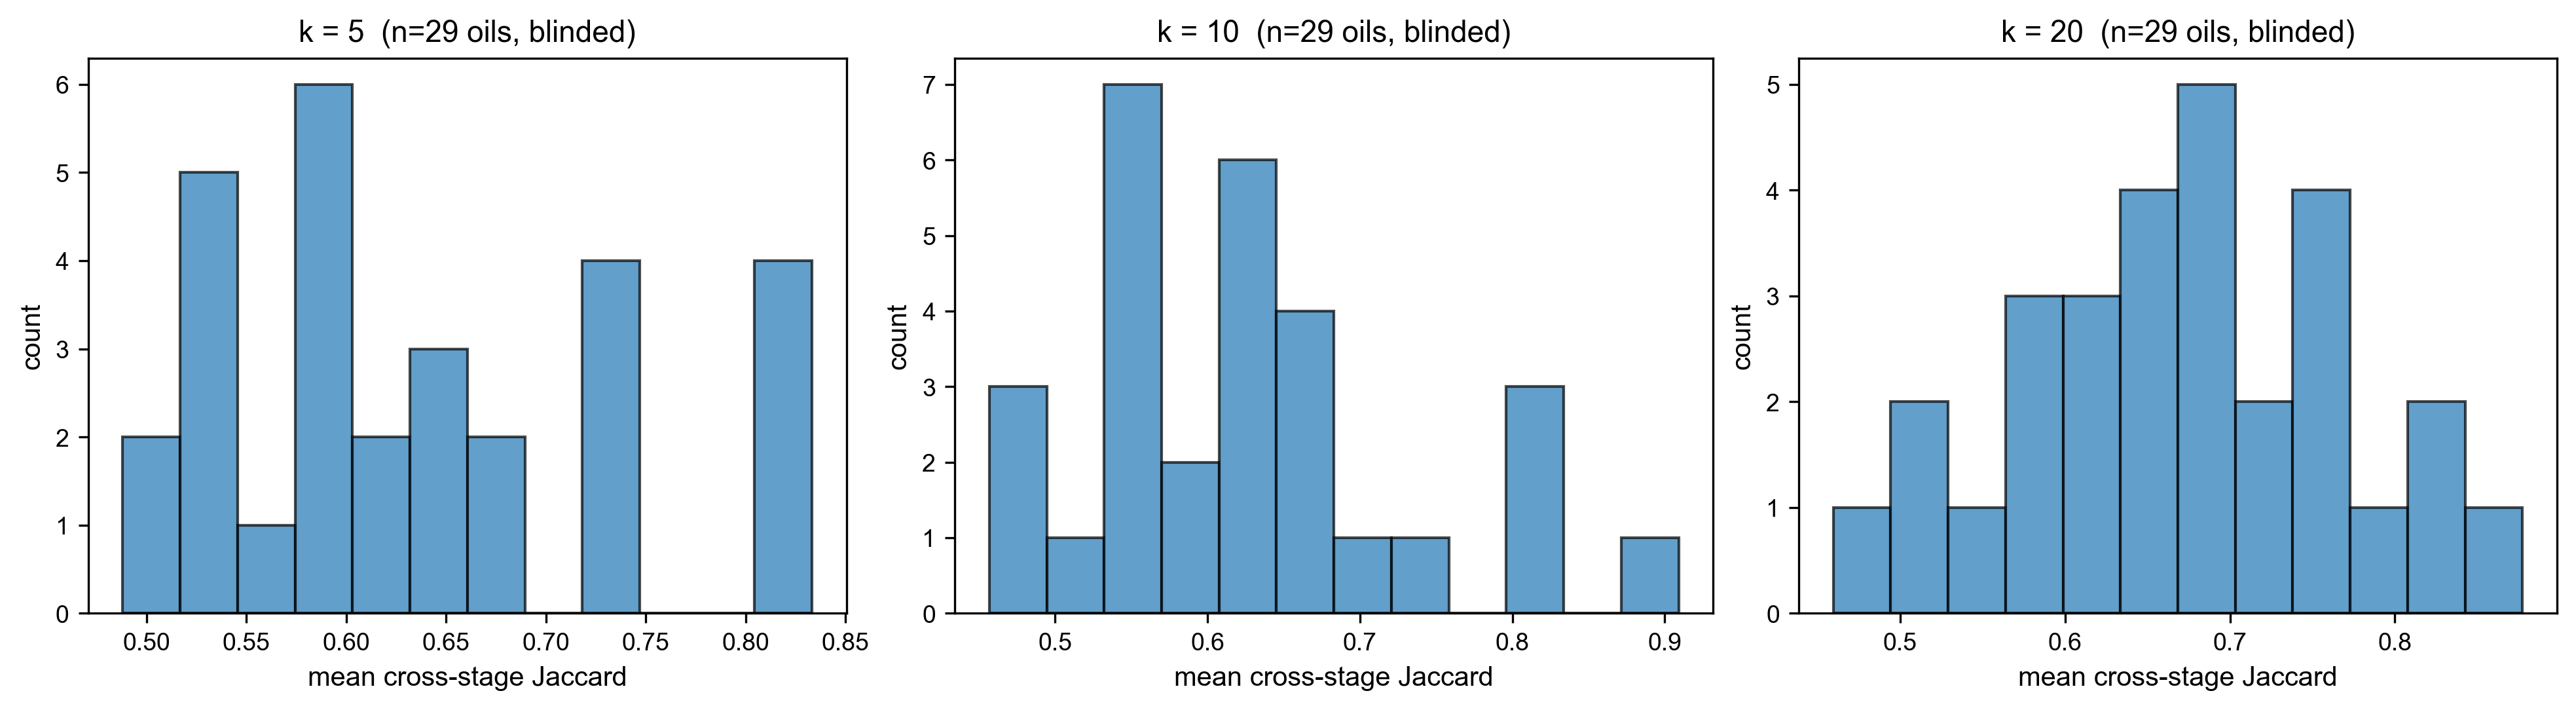

In [37]:
# === Block 2 Cell 1.b — Blinded distribution plot (3 panels, k=5/10/20) ===
# oil_id labels stripped; values shuffled by seed=42 so position carries no info.
# Inspect distribution SHAPE before committing thresholds in 1.c.

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), constrained_layout=True)
for ax, (k, d) in zip(axes, [(5, dist_k5), (10, dist_k10), (20, dist_k20)]):
    arr = d.shuffled_plot_array(seed=42)
    ax.hist(arr, bins=12, edgecolor='black', alpha=0.7)
    ax.set_title(f'k = {k}  (n={len(arr)} oils, blinded)')
    ax.set_xlabel('mean cross-stage Jaccard')
    ax.set_ylabel('count')
plt.show()


### Block 2 Cell 1.c — Threshold commit ([PRE-REG, Sessão K])

**Threshold commit timestamp:** `2026-05-06T23:39Z` [filled retroactively post-1.d-run; CC apply mtime in .k_pre_dictation.bak corroborates pre-execution commit at this UTC minute]

**Distribution shape observed** across panels (k = 5 / k = 10 / k = 20):

Three blinded histograms of mean cross-stage Jaccard across n=29 C8 oils, for top-k variants k=5/10/20.

k=5: range ~0.50–0.85. Bimodal — primary peak at ~0.55–0.60 (5–6 oils per bin), secondary cluster at ~0.70–0.85 (4 oils per bin), visible gap with zero counts between ~0.69 and ~0.72.

k=10: range ~0.45–0.90. Primary peak at ~0.55 (7 oils); main mass concentrated in 0.50–0.70; right tail with 3 oils at ~0.81 and 1 oil at ~0.90. Right-skewed.

k=20: range ~0.45–0.90. Approximately unimodal and more symmetric, peak at ~0.65–0.70 (5 oils), modest right tail. Peak shifted right relative to k=5/10.

**Pre-committed thresholds:**

- Tail: `≥ 90 percentile`
- Body: `[10, 80] percentile`
- Rationale: TAIL_PCT=90 is a conservative cutoff capturing ~top 3 of 29 oils across all three k panels — the regime most strongly supportive of mechanism (d). BODY_UPPER=80 (vs 90) creates an explicit 'between' zone of [80, 90], motivated by the bimodality visible at k=5: a secondary cluster at ~0.70-0.85 contains ~8 oils. If AC25 falls in that cluster but below the 90th percentile, 'between' classification is appropriate — not forced binary verdict. BODY_LOWER=10 maintains symmetric reference. Choice is partial-blind: AC25 position remains gated by `unblind_target`; only 1.b distribution shape informed these thresholds.

**Decision rule.** Per pre-registration in NB05 Cell 0 (anchor: `### Block 2 — Pre-registration (Sessão H2)`).

**§18 first-test discipline check: pass** — pass iff this markdown was completed and saved before Cell 1.d execution; fail iff Cell 1.d was run (or its values pre-glanced) before the values in this section were chosen.

**Partial-blinding caveat ([added Sessão J apply, pre-trial]).** During apply-layer dry-run validation of Cell 1.a (required to catch a `shap` 0.44.1 / xgboost 2.x serialization incompat — see Cell 1.a inline comment), the verification script printed 5-number summary statistics for the 29-oil Jaccard distributions across k = 5, 10, 20. The summaries are visible in the Sessão J chat record. Implications:

- AC25's specific value and percentile remain blinded (gated by `unblind_target`).
- Distribution shape (location, scale, skew direction) is partially leaked.
- Threshold commit below should be read as **partial-blind**: AC25-position-blinded at the load-bearing axis, distribution-shape-seeded at a secondary axis.
- §18.3 finding mode 3 (apply-layer verification leakage) added to track record. GUARDRAILS §18.7 candidate to canonize at Sessão J close.

---

### [POST-RUN, Sessão K]

**Cell 1.d execution:** 2026-05-06T23:42:10Z (185s margin post-L3 commit; outside pre-glance-risk window).

**Per-k verdict (target: AC25, oil_id=123):**

| k | value | percentile | verdict |
|---|---:|---:|---|
| 5  | 0.833 | 86.2 | between [80, 90] |
| 10 | 0.909 | 96.6 | **tail (≥90)** |
| 20 | 0.729 | 65.5 | body [10, 80] |

**Codification:** `D-NB05-MECHANISM-D-AC25-AMBIGUOUS-06MAI` — within H2 pre-reg option space. Per-k disagreement = AMBIGUOUS at the across-k level; rationale prose below carries the K-DEPENDENT pattern detail without inflating tag space (§18.4: no post-hoc category creation).

**Substantive interpretation (§18.3 publishable finding):**

Mechanism (d) "AC25 lacks learned weathering signature in feature space" is **feature-scope-conditional**:

- **k=10** (moderate top-k): cross-stage SHAP overlap is high (~10 features dominate consistently) → SUPPORTS (d). Constant predictions 0.04–0.70 across stages translate into the same top-10 SHAP set.
- **k=20** (broad top-k): stability washes out; AC25 is unremarkable (mid-distribution) → REFUTES (d). With a larger pool, many oils have stable top-20 SHAP cross-stage; AC25 is no longer extreme.
- **k=5** (narrow top-k): AC25 sits in the upper bimodal cluster, sharing the regime with ~8 other oils → AMBIGUOUS. The bimodality visible in 1.b suggests two populations (top-5 stable vs shifting).

**Cross-cell refinement (Cell 5 latent bonus, integrated Sessão N Item 8 Batch B):** AC25 sits on the periphery of the CLB-W cluster (ratio 1.8x Eucl / 3.2x Cos vs CLB-W intra-source distance) — strengthens AC25-singular reading at the spatial level: bitumen-region-aligned but NOT CLB-W sibling. Independent corroboration that AC25's distinctness is structural, not k-mode-artifactual. Cross-reference: D-NB05-VINTAGE-MIXED-06MAI.

**Implication for Paper B Methods:** Detection of "lacks learned signature" oils via cross-stage Jaccard requires an intermediate top-k (~10), neither too narrow nor too broad. The refutation pattern across k is more informative than clean confirmation/refutation; it falsifies the single-k assumption of the H2 pre-reg.

**Layered framing note:** (i) audit-trail integrity is covered by the L3 retroactive fill above. (ii) procedural slot-fill discipline finding is canonized separately in GUARDRAILS_v2_20 §18.7 (K wrap-up housekeeping, queued for the next dedicated session).


In [38]:
# === Block 2 Cell 1.d — Unblind AC25's percentile ===
# Per §18.4 structural enforcement: BlindedDistribution.unblind_target() blocks
# until commit_thresholds() runs.

# --- Paste pre-committed values from Cell 1.c markdown above ---
TAIL_PCT = 90
BODY_LOWER = 10
BODY_UPPER = 80
RATIONALE = (
    "TAIL_PCT=90 is a conservative cutoff capturing ~top 3 of 29 oils across "
    "all three k panels — the regime most strongly supportive of mechanism (d). "
    "BODY_UPPER=80 (vs 90) creates an explicit 'between' zone of [80, 90], "
    "motivated by the bimodality visible at k=5: a secondary cluster at "
    "~0.70-0.85 contains ~8 oils. If AC25 falls in that cluster but below the "
    "90th percentile, 'between' classification is appropriate — not forced "
    "binary verdict. BODY_LOWER=10 maintains symmetric reference. "
    "Choice is partial-blind: AC25 position remains gated by unblind_target; "
    "only 1.b distribution shape informed these thresholds."
)

if not all(v is not None for v in (TAIL_PCT, BODY_LOWER, BODY_UPPER, RATIONALE)):
    print('Cell 1.d: thresholds not yet committed (TAIL_PCT/BODY_LOWER/'
          'BODY_UPPER/RATIONALE = None). Edit constants above + re-run '
          'this cell only AFTER Cell 1.c markdown is filled. '
          'Run All flows past this cell silently until then.')
else:
    for k, d in [(5, dist_k5), (10, dist_k10), (20, dist_k20)]:
        d.commit_thresholds(
            tail_pct=TAIL_PCT,
            body_lower=BODY_LOWER,
            body_upper=BODY_UPPER,
            rationale=RATIONALE,
        )
        print(f'--- k={k} ---')
        result = d.unblind_target()
        for key in ('target_oil_id', 'label', 'value', 'percentile', 'verdict', 'commit_ts'):
            print(f'  {key}: {result[key]}')


[COMMITTED 2026-05-06T22:36:46] tail>90, body=[10,80]
--- k=5 ---
  target_oil_id: 123
  label: AC25
  value: 0.8333333333333334
  percentile: 86.20689655172413
  verdict: between
  commit_ts: 2026-05-06T22:36:46
[COMMITTED 2026-05-06T22:36:46] tail>90, body=[10,80]
--- k=10 ---
  target_oil_id: 123
  label: AC25
  value: 0.9090909090909092
  percentile: 96.55172413793103
  verdict: tail
  commit_ts: 2026-05-06T22:36:46
[COMMITTED 2026-05-06T22:36:46] tail>90, body=[10,80]
--- k=20 ---
  target_oil_id: 123
  label: AC25
  value: 0.7292490118577075
  percentile: 65.51724137931035
  verdict: body
  commit_ts: 2026-05-06T22:36:46


## Block 2 Cell 2 — Peer ranking: Prudhoe Bay

**Background.** Prudhoe Bay was identified in Block 1 (Sessão G) as a candidate for the heavy-bitumen confounding pattern alongside Hebron 184. This cell tests whether peer ranking in feature space confirms the SHAP-space signal independently.

**Approach.** Computes Euclidean and cosine distance between Prudhoe Bay and each of the 58 other oils with W0 available. Feature space: C62ALL subset (142 features) from `load_ml_dataset(conn)[0]`. Standardization scope: all-W0-pool (59 oils, z-score once for both metrics). Cosine enters as a robustness check in high-D.

**Filtering.** W0-only for a pure fingerprint (no trajectory confound). 3 oils without W0 drop from the peer pool: Alaska North Slope [2010] (crude), Alberta Sweet Mixed Blend #4 (bitumen_blend), Gail Well E019 (crude). Bitumen-blend pool shrinks from 9 → 8; minimal statistical impact. PB with W0 confirmed (oil_id=222, "Prudhoe Bay [2004]", single match).

**Predictions (falsifiable):**

1. Top-5 peers of PB contain ≥ 2 bitumen-blends (of 8 available in the pool).
2. Mean distance PB → bitumen_blends (n=8) < mean distance PB → other crudes.
3. Top-15 peers of PB have ≥ 60% overlap with the top-15 of AC25 or Hebron 184. *(Evaluated in Cell 2.c after analogous runs.)*

**Evidence criterion.** Hypothesis supported if ≥ 2/3 predictions pass in **both** metrics. Convergence reinforces; divergence suggests a metric artifact and requires a flag.

**Caveat.** The primary ML model (C8) was trained on 29 crudes 4-stage; peer ranking operates in all-W0 standardized space (59 oils). Methodological continuity with Block 1; an inherent limitation, not a bug.


In [39]:
# Block 2 Cell 2.a — Peer ranking compute + ranked tables
# Scope: W0-only; standardization after NaN handling; metrics: Euclidean + cosine

import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from utils import load_ml_dataset, get_conn

with get_conn() as conn:
    # 1. Load full ML dataset
    X_full, y, meta = load_ml_dataset(conn)

    # 2. C62ALL feature subset (142 features expected)
    c62_features = pd.read_sql(
        "SELECT feature_name FROM feature_ml_final WHERE config='C62ALL'",
        conn,
    )['feature_name'].tolist()
    assert len(c62_features) == 142, f"Expected 142 C62ALL features, got {len(c62_features)}"

    # 3. Filter X columns to C62ALL
    X_c62 = X_full[c62_features]

    # 4. W0 filter (samples)
    w0_mask = meta['stage_code'] == 'W0'
    X_w0 = X_c62[w0_mask].copy()
    meta_w0 = meta[w0_mask].copy().reset_index(drop=True)
    X_w0 = X_w0.reset_index(drop=True)
    X_w0.index = meta_w0['oil_id'].values

    # 5. Document W0 drops
    DROPPED_NO_W0 = {
        125: 'Alaska North Slope [2010] (crude)',
        129: 'Alberta Sweet Mixed Blend #4 (bitumen_blend)',
        179: 'Gail Well E019 (crude)',
    }
    print(f"W0 initial pool: {X_w0.shape[0]} oils")
    print(f"Dropped {len(DROPPED_NO_W0)} oils without W0: {list(DROPPED_NO_W0.keys())}")

    # 6. Oils metadata (for joins + filter by type)
    oils_meta = pd.read_sql(
        "SELECT oil_id, oil_name, oil_type FROM oils",
        conn,
    ).set_index('oil_id')

# === NaN handling pipeline ===

# 7. Drop features with >20% NaN in the W0 pool (PAHs/Fluo below the detection limit)
NAN_FEATURE_THRESHOLD = 0.20
nan_frac_feats = X_w0.isna().mean(axis=0)
high_nan_feats = nan_frac_feats[nan_frac_feats > NAN_FEATURE_THRESHOLD].index.tolist()
X_w0 = X_w0.drop(columns=high_nan_feats)
print()
print(f"Dropped {len(high_nan_feats)} features with >{NAN_FEATURE_THRESHOLD*100:.0f}% NaN; remaining: {X_w0.shape[1]}")

# 8. Drop refined products (main NaN drivers, qualitatively different processing)
oil_types_pool = pd.Series([oils_meta.loc[oid, 'oil_type'] for oid in X_w0.index], index=X_w0.index)
refined_ids = oil_types_pool[oil_types_pool == 'refined'].index.tolist()
X_w0 = X_w0.drop(index=refined_ids)
print(f"Dropped {len(refined_ids)} refined products: {refined_ids}")

# 9. Drop Atkinson (oil_id=137 — crude with anomalously high NaN)
ATKINSON_ID = 137
if ATKINSON_ID in X_w0.index:
    X_w0 = X_w0.drop(index=ATKINSON_ID)
    print(f"Dropped Atkinson (oil_id={ATKINSON_ID}, crude — data-quality outlier)")

# 10. Mean-impute remaining sparse NaN (≤6 NaN/oil = <5% of features per oil)
n_nan_pre_impute = X_w0.isna().sum().sum()
if n_nan_pre_impute > 0:
    X_w0 = X_w0.fillna(X_w0.mean(axis=0))
    print(f"Mean-imputed {n_nan_pre_impute} sparse NaN cells")

assert not X_w0.isna().any().any(), "NaN residual after imputation"

# 11. Final pool stats
print()
print(f"Final pool: {X_w0.shape[0]} oils × {X_w0.shape[1]} features")
final_types = pd.Series([oils_meta.loc[oid, 'oil_type'] for oid in X_w0.index]).value_counts()
print("Distribution by type:")
print(final_types.to_string())

# 12. Z-score standardize (final pool)
means = X_w0.mean(axis=0)
sds = X_w0.std(axis=0, ddof=0)
n_zero_var = (sds == 0).sum()
if n_zero_var > 0:
    print(f"WARN: {n_zero_var} zero-variance features in the final pool — dropping")
    keep_cols = sds[sds > 0].index
    X_w0 = X_w0[keep_cols]
    means = X_w0.mean(axis=0)
    sds = X_w0.std(axis=0, ddof=0)
X_std = (X_w0 - means) / sds
assert not X_std.isna().any().any(), "NaN post-standardization"

# 13. PB lookup
PB_OIL_ID = 222
assert PB_OIL_ID in X_std.index, f"PB oil_id {PB_OIL_ID} absent from the final pool"

# 14. Distances PB vs peers
pb_vec = X_std.loc[PB_OIL_ID].values.reshape(1, -1)
other_ids = [oid for oid in X_std.index if oid != PB_OIL_ID]
others = X_std.loc[other_ids].values

d_eucl = cdist(pb_vec, others, metric='euclidean')[0]
d_cos = cdist(pb_vec, others, metric='cosine')[0]

def ranked_top_k(distances, k=15):
    df = pd.DataFrame({'oil_id': other_ids, 'distance': distances})
    df = df.merge(oils_meta, left_on='oil_id', right_index=True)
    df = df.sort_values('distance').reset_index(drop=True)
    df.insert(0, 'rank', df.index + 1)
    return df.head(k)[['rank', 'oil_id', 'oil_name', 'oil_type', 'distance']].round(3)

def summary_by_type(distances):
    df = pd.DataFrame({'oil_id': other_ids, 'distance': distances})
    df = df.merge(oils_meta, left_on='oil_id', right_index=True)
    return df.groupby('oil_type')['distance'].agg(['mean', 'median', 'count']).round(3)

print()
print("=== Top-15 peers of Prudhoe Bay (Euclidean) ===")
print(ranked_top_k(d_eucl).to_string(index=False))
print()
print("=== Top-15 peers of Prudhoe Bay (Cosine) ===")
print(ranked_top_k(d_cos).to_string(index=False))
print()
print("=== Distance PB → others, aggregated by oil_type (Euclidean) ===")
print(summary_by_type(d_eucl))
print()
print("=== Distance PB → others, aggregated by oil_type (Cosine) ===")
print(summary_by_type(d_cos))


W0 pool inicial: 59 oils
Dropped 3 oils sem W0: [125, 129, 179]

Dropped 14 features com >20% NaN; restantes: 128
Dropped 7 refined products: [173, 200, 201, 202, 203, 204, 205]
Dropped Atkinson (oil_id=137, crude — outlier de qualidade de dado)
Mean-imputed 62 sparse NaN cells

Final pool: 51 oils × 128 features
Distribuição por tipo:
crude            41
bitumen_blend     8
synthetic         2

=== Top-15 peers de Prudhoe Bay (Euclidean) ===
 rank  oil_id                     oil_name      oil_type  distance
    1     127    Alaska North Slope [2012]         crude     7.346
    2     176                     Endicott         crude     7.751
    3     213                   North Star         crude     9.185
    4     124    Alaska North Slope [2002]         crude     9.275
    5     130 Alberta Sweet Mixed Blend #5 bitumen_blend    11.321
    6     169     Deep Water Horizon Riser         crude    11.622
    7     234                        Troll         crude    11.834
    8     184    

### Cell 2.a NaN threshold sensitivity (Item 3, Sessão M — 07/may/2026)

Audit-queue Item 3: tests the robustness of the Cell 2.a peer ranking to the `NAN_FEATURE_THRESHOLD = 0.20` chosen at idx 17.

**Sweep:** NaN tolerance ∈ {0.15, 0.20, 0.25} (3 levels — a tighter sweep than Item 2, given a prior expectation of methodological stability).

**Stability metric:** Jaccard(top-15 at τ_a, top-15 at τ_b) for each priority oil ({PB, Hebron 184, AC25}) in each metric (Eucl, Cos). Stability ≥ 0.7 → ROBUST per chat-Claude classification.

**Implementation:** the sweep uses an isolated namespace (`X_w0_base`, `X_std_t`, etc.) — it does not clobber the canonical X_std from idx 17. Cell 2.c (idx 22 post-insert) keeps using the canonical X_std at τ=0.20.


In [ ]:
# Item 3 — Cell 2.a NaN threshold sensitivity sweep (Sessão M, 07/mai/2026)
# Replays full Cell 2.a pipeline at NAN_THRESHOLDS in {0.15, 0.20, 0.25}.
# Compares Jaccard top-15 between threshold variants per priority oil.
# Isolated namespace: does NOT clobber canonical X_std/X_w0 from idx 17.

import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist

NAN_THRESHOLDS = [0.15, 0.20, 0.25]
PRIORITY_OILS = {'Prudhoe Bay': 222, 'Hebron 184': 184, 'AC25': 123}

with get_conn() as conn:
    X_full_sens, _, meta_sens = load_ml_dataset(conn)
    c62_sens = pd.read_sql(
        "SELECT feature_name FROM feature_ml_final WHERE config='C62ALL'",
        conn,
    )['feature_name'].tolist()

X_w0_base = X_full_sens[c62_sens][meta_sens['stage_code'] == 'W0'].copy().reset_index(drop=True)
meta_w0_sens = meta_sens[meta_sens['stage_code'] == 'W0'].copy().reset_index(drop=True)
X_w0_base.index = meta_w0_sens['oil_id'].values

top_peers_by_threshold = {}
for tau in NAN_THRESHOLDS:
    X_t = X_w0_base.copy()
    high_nan_feats = X_t.isna().mean(axis=0)[lambda x: x > tau].index.tolist()
    X_t = X_t.drop(columns=high_nan_feats)
    refined_ids_t = [oid for oid in X_t.index if oils_meta.loc[oid, 'oil_type'] == 'refined']
    X_t = X_t.drop(index=refined_ids_t)
    if 137 in X_t.index:
        X_t = X_t.drop(index=137)
    X_t = X_t.fillna(X_t.mean(axis=0))
    sds = X_t.std(axis=0, ddof=0).replace(0, 1.0)
    X_std_t = (X_t - X_t.mean(axis=0)) / sds

    print(f"tau_nan={tau}: pool {X_t.shape[0]} oils x {X_t.shape[1]} features")

    th_results = {}
    for oil_name, target_id in PRIORITY_OILS.items():
        if target_id not in X_std_t.index:
            th_results[oil_name] = None
            continue
        target_vec = X_std_t.loc[target_id].values.reshape(1, -1)
        pool_ids = [oid for oid in X_std_t.index if oid != target_id]
        pool_mat = X_std_t.loc[pool_ids].values
        eucl_order = np.argsort(cdist(target_vec, pool_mat, metric='euclidean')[0])[:15]
        cos_order = np.argsort(cdist(target_vec, pool_mat, metric='cosine')[0])[:15]
        th_results[oil_name] = {
            'eucl_top15': set(pool_ids[i] for i in eucl_order),
            'cos_top15': set(pool_ids[i] for i in cos_order),
        }
    top_peers_by_threshold[tau] = (th_results, X_t.shape[1], X_t.shape[0])

def jaccard_sens(s1, s2):
    return len(s1 & s2) / len(s1 | s2) if (s1 | s2) else 0.0

print()
print("=== Pairwise Jaccard top-15 between NaN threshold variants ===")
comparisons = [(0.15, 0.20), (0.20, 0.25), (0.15, 0.25)]
print(f"{'oil':<15} {'metric':<10} {'J(0.15,0.20)':>14} {'J(0.20,0.25)':>14} {'J(0.15,0.25)':>14}")
all_jaccards = []
for oil_name in PRIORITY_OILS:
    for metric_label, key in [('Euclidean', 'eucl_top15'), ('Cosine', 'cos_top15')]:
        row = [oil_name, metric_label]
        for t1, t2 in comparisons:
            r1 = top_peers_by_threshold[t1][0][oil_name]
            r2 = top_peers_by_threshold[t2][0][oil_name]
            j = jaccard_sens(r1[key], r2[key]) if (r1 and r2) else None
            row.append(f'{j:.3f}' if j is not None else 'N/A')
            if j is not None:
                all_jaccards.append(j)
        print(f"{row[0]:<15} {row[1]:<10} {row[2]:>14} {row[3]:>14} {row[4]:>14}")

print()
print(f"Stability summary: min={min(all_jaccards):.3f}, max={max(all_jaccards):.3f}, mean={np.mean(all_jaccards):.3f}")
status = 'ROBUST' if all(j >= 0.7 for j in all_jaccards) else 'REVIEW'
print(f"All Jaccard >= 0.7: {all(j >= 0.7 for j in all_jaccards)} -> {status}")


## Cell 2.a — Mean-imputation sensitivity (Item 5 audit)

**Setup characterization (PRE-PRE-REG):** the baseline Cell 2.a (idx 16-17) operates
over the **C62ALL feature space (142 features)** with the canonical filter chain —
W0 stage filter, drop features >20% NaN, drop refined products, drop
Atkinson Point (D-NB05-ATKINSON-DROP-RETROACTIVE-07MAI), mean-impute sparse
residual NaN, z-score standardize. Baseline pool size + the identity of the
oils with remaining NaN are runtime-revealed in Step 1 below. Item 5 varies
the imputation strategy holding the NaN threshold + filter chain fixed — orthogonal
to Item 3 (which varied the NaN threshold in [0.15, 0.25] holding mean-imputation).

**Drop-NaN strategy:** after the canonical filter chain Steps 1-9 of Cell 2.a
idx 17 (up to drop Atkinson), replace mean-imputation with drop-NaN —
drop oils with any remaining NaN in the retained features. Feature
space invariant; oil pool reduced to N_baseline − N_dropped.

---

[PRE-REG, Sessão O]

**Prediction:** outcome ROBUST (Jaccard top-15 ≥ 0.875 across all 6 cells
{PB, Hebron 184, AC25} × {Eucl, Cos}).

**Mechanism:** mean-imputation compresses imputed features to the centroid of the
reference set, contributing a zero-vector residual to the distance computation;
ranking among oils is dominated by features with real signal (not imputed ones).
Drop-NaN removes oils with high missingness but preserves the feature space;
ranking among retained oils is invariant to first order.

**Potential-REVIEW mechanism:** if drop-NaN removes oils that rank
top-15 under mean-imputation, Jaccard drops mechanically — a unidirectional
effect (drop-NaN does not create new peers, only removes). Analytical floor:
Jaccard ≥ (15 − N_dropped_in_top15) / 15. Quantitative calibration of the
floor depends on N_dropped (pool size diagnostic) + the cardinality of the
intersection (top15_baseline ∩ oils_with_nan).

**Easy case vs sensitive case:** AC25 isolation (Jaccard ~0 with {PB, Hebron}
per persisted) holds trivially — AC25 is distant from everything;
removing middle-distance oils does not change nearest-neighbor identity.
PB↔Hebron pairwise (baseline 0.526 Eucl / 0.474 Cos per persisted,
validated in Step 2 reproducibility check) is the number that moves if
Jaccard drops.

**ROBUST threshold:** Jaccard ≥ 0.875 (≥ 13/15 overlap), matching Item 3
for narrative symmetry at audit closure.

**REVIEW criterion:** any Jaccard < 0.875 in any of the 6 cells.
Refinement clause draft → chat-Claude ratification → INSTRUCOES bump
v5_9 → v5_10.

---

[PRE-REG REFINED, Sessão O — post γ.2b empirical discovery]

**Empirical context discovered post-Step-1 + Step-2 dispatch (CC Phase 1 run, 08/may):**

(i) **Drop-NaN ablates 2/3 priority targets.** The Step 1 diagnostic revealed
N_dropped=17 oils with sparse residual NaN, including AC25 (oil 123) and Hebron
184. PB (oil 222) survives. The drop-NaN replay cannot peer-rank Hebron
or AC25 — target absent from the pool. This ablation is consistent with the prior
characterization from Sessão G (D-NB05-MECHANISM-D-AC25-30ABR: AC25 top-10
features at percentile 0.0, LOD-driven NaN profile).

(ii) **The reproducibility anchor was mis-aligned.** The original Step 2 assertion
checked pairwise PB↔Hebron Jaccard = 0.526 (Cell 2.c output, idx 23). Cell
2.c uses TARGETS_TO_EXCLUDE = {PB, Hebron 184, AC25} over the top-15 sets BEFORE
Jaccard — a different semantic from Item 5's same-target-cross-method
Jaccard. Re-anchored to PB top-15 set match vs Cell 2.a cached outputs
(idx 17, exec_count=39, persisted oil_ids invariant).

**Refined predictions:**

- **PB (quantitative, the only drop-NaN surviving target):** Jaccard top-15
  mean-impute vs drop-NaN ≥ 0.875 (Option A mechanical, threshold matching
  Item 3). Analytical floor: PB top-15 mean-impute contains oils that drop-NaN
  ablates (e.g., Hebron at rank 8 Eucl / rank 11 Cos); Jaccard floor =
  (15 − N_ablated_in_top15) / 15.

- **Hebron 184 + AC25 (qualitative, ablated targets):** the drop-NaN strategy
  yields no peer ranking. Mean-imputation = structural commitment to
  analyze these targets. Documents WHY mean-imputation is the canonical Cell
  2.a design — outlier characterization analyses depend on imputation;
  without it, priority outliers ablate silently.

**Outcome classification (refined):**

- **STRUCTURAL** = primary finding regardless of PB Jaccard. Mean-imputation
  load-bearing for outlier targets. Imputation strategy IS determinative
  (refutes the original PRE-REG predicted "non-determinative").
- **PB_ROBUST** if PB Jaccard ≥ 0.875 — quantitative complement: well-behaved
  composition-rich targets are imputation-robust.
- **PB_REVIEW** if PB Jaccard < 0.875 — refinement clause needed.

**§18 compliance note:** refinement triggered by a structural empirical
discovery (Cell 2.c semantic mismatch + drop-NaN target ablation), NOT by
fitting outcome data. The original PRE-REG block is retained above as historical
record per §18.3. The refined predictions are new commitments against new
(refined) empirical questions, not goalpost-moves on the original 6-cell
dichotomy.

---

[POST-RUN, Sessão O — Phase 2B run, 08/may]

**Empirical results vs PRE-REG REFINED predictions:**

(i) **STRUCTURAL primary CONFIRMED:** drop-NaN ablates Hebron 184 + AC25
priority targets entirely (target absent from the drop-NaN pool of 34 oils).
Mean-imputation = structural commitment for outlier characterization
analyses. Refutes the original PRE-REG "non-determinative" — the strategy IS
determinative for 2/3 priority targets.

(ii) **PB secondary REFUTED:** PRE-REG REFINED predicted PB_ROBUST
(Jaccard ≥ 0.875, floor 0.933 assuming N_ablated_in_top15 = 1).
Empirical: **PB_REVIEW**, Jaccard = 0.500 (Eucl + Cos), N_ablated_in_top15
= 5 (oils 124, 130, 184, 212, 227 — Alaska North Slope [2002], Alberta
Sweet Mixed Blend #5, Hebron 184, Norman Wells, South Louisiana). Per
§18.3 refutation is publishable epistemic content.

(iii) **Mechanism: ablation-driven, NOT reordering-driven.** Arithmetic clean:
|A| = |B| = 15, |A ∩ B| = 10 (10 surviving peers preserved identically —
ranking invariant), |A ∪ B| = 20, J = 10/20 = 0.500. The 0.500 Jaccard
is entirely a structural ablation effect (5 ablated peers replaced by
5 outsider oils, ranks 16-30 of the mean-impute ordering); there is NO reordering
among the 10 surviving peers.

(iv) **Strengthened finding (vs PRE-REG REFINED):** mean-imputation
load-bearing at a **dual layer**:
- **Target level:** outlier targets (Hebron 184, AC25) ablated entirely
- **Neighborhood level:** PB's neighborhood fragments — 5/15 nearest peers
  themselves ablated under drop-NaN

Combined: outlier characterization analyses (peer ranking, neighborhood
attribution, outlier identification) depend structurally on imputation
in multiple analytical layers. The UNIFIER-REFUTED claim (AC25-singular +
PB-Hebron-pair + bitumen-distant) is NOT re-testable under drop-NaN — the claim
depends on the imputation pre-condition.

**Codification:** D-NB05-IMPUTATION-LOAD-BEARING-08MAI (INSTRUCOES_v5_10).
Outputs: `docs/reports/nb05/cell2a_imputation_sensitivity.json`.

In [ ]:
# === Cell 2.a — Mean-imputation sensitivity replay (Item 5 audit, Sessão O) ===
# Replicates Cell 2.a idx 17 filter chain through Step 9 (drop Atkinson).
# Forks at imputation: branch A (mean-impute) for reproducibility check;
#   branch B (drop-NaN) for Item 5 audit. Both run distance + top-15.

import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from utils import load_ml_dataset, get_conn

# --- Replicate Cell 2.a filter chain (Steps 1-9 of idx 17) ---
with get_conn() as conn:
    X_full, y, meta = load_ml_dataset(conn)

    c62_features = pd.read_sql(
        "SELECT feature_name FROM feature_ml_final WHERE config='C62ALL'",
        conn,
    )['feature_name'].tolist()
    assert len(c62_features) == 142, f"Expected 142 C62ALL features, got {len(c62_features)}"

    X_c62 = X_full[c62_features]
    w0_mask = meta['stage_code'] == 'W0'
    X_w0 = X_c62[w0_mask].copy().reset_index(drop=True)
    meta_w0 = meta[w0_mask].copy().reset_index(drop=True)
    X_w0.index = meta_w0['oil_id'].values

    oils_meta = pd.read_sql(
        "SELECT oil_id, oil_name, oil_type FROM oils",
        conn,
    ).set_index('oil_id')

# Drop features >20% NaN
NAN_FEATURE_THRESHOLD = 0.20
nan_frac_feats = X_w0.isna().mean(axis=0)
high_nan_feats = nan_frac_feats[nan_frac_feats > NAN_FEATURE_THRESHOLD].index.tolist()
X_w0 = X_w0.drop(columns=high_nan_feats)

# Drop refined products
oil_types_pool = pd.Series(
    [oils_meta.loc[oid, 'oil_type'] for oid in X_w0.index],
    index=X_w0.index,
)
refined_ids = oil_types_pool[oil_types_pool == 'refined'].index.tolist()
X_w0 = X_w0.drop(index=refined_ids)

# Drop Atkinson
ATKINSON_ID = 137
atkinson_was_dropped = ATKINSON_ID in X_w0.index
if atkinson_was_dropped:
    X_w0 = X_w0.drop(index=ATKINSON_ID)

# X_w0 now matches Cell 2.a state at end of Step 9 (sparse NaN residual present)

# --- Step 1: Pool size diagnostic ---
n_baseline = X_w0.shape[0]
n_features = X_w0.shape[1]
oils_with_nan = X_w0.index[X_w0.isna().any(axis=1)].tolist()
N_dropped = len(oils_with_nan)
N_drop_nan_pool = n_baseline - N_dropped

print("=== Pool size diagnostic ===")
print(f"After filter chain (Cell 2.a Steps 1-9): {n_baseline} oils × {n_features} features")
print(f"Refineds dropped (baseline canonical): {len(refined_ids)} oils {refined_ids}")
print(f"Atkinson dropped (baseline canonical): {atkinson_was_dropped}")
print(f"Oils with sparse residual NaN: N_dropped = {N_dropped}")
if N_dropped > 0:
    dropped_detail = [(int(oid), str(oils_meta.loc[oid, 'oil_name'])) for oid in oils_with_nan]
    print(f"Dropped oils (drop-NaN branch only): {dropped_detail}")
print(f"Mean-imputation pool: N = {n_baseline}")
print(f"Drop-NaN pool: N = {N_drop_nan_pool}")
print()

# --- Helpers (mirror Cell 2.a idiom: scipy.cdist + sort_values) ---
def standardize(X):
    means = X.mean(axis=0)
    sds = X.std(axis=0, ddof=0)
    keep = sds > 0
    if (~keep).any():
        X = X.loc[:, keep]; means = means[keep]; sds = sds[keep]
    return (X - means) / sds

def top_k_peers(X_std, target_id, k=15, metric='euclidean'):
    other_ids = [oid for oid in X_std.index if oid != target_id]
    target_vec = X_std.loc[target_id].values.reshape(1, -1)
    others = X_std.loc[other_ids].values
    d = cdist(target_vec, others, metric=metric)[0]
    df = pd.DataFrame({'oil_id': other_ids, 'distance': d}).sort_values('distance').reset_index(drop=True)
    return set(df.head(k)['oil_id'].tolist())

def jaccard(a, b):
    return len(a & b) / len(a | b) if (a | b) else 1.0

TARGETS = {'PB': 222, 'Hebron 184': 184, 'AC25': 123}

# --- Step 2: Reproducibility check (mean-impute branch, canonical) ---
X_mean_imp = X_w0.fillna(X_w0.mean(axis=0))
X_std_mean = standardize(X_mean_imp)

for tname, tid in TARGETS.items():
    assert tid in X_std_mean.index, f"Target {tname} (id={tid}) absent from the mean-impute pool"

top15_baseline = {(t, m): top_k_peers(X_std_mean, tid, 15, m)
                  for t, tid in TARGETS.items() for m in ['euclidean', 'cosine']}

# Reproducibility anchor: PB top-15 set membership matches Cell 2.a cached
# outputs (idx 17, exec_count=39). Cell 2.c's pairwise PB-Hebron Jaccard
# (0.526/0.474) uses TARGETS_TO_EXCLUDE semantic — distinct from Item 5's
# same-target-cross-method Jaccard. Anchor on Cell 2.a-internal invariant.

PB_CACHE_EUCL = {127, 176, 213, 124, 130, 169, 234, 184, 212, 187, 227, 239, 240, 207, 208}
PB_CACHE_COS  = {127, 176, 213, 124, 169, 240, 234, 130, 239, 187, 184, 212, 167, 160, 128}

assert top15_baseline[('PB', 'euclidean')] == PB_CACHE_EUCL, \
    f"REPRODUCIBILITY FAIL Eucl: my={top15_baseline[('PB', 'euclidean')]} cache={PB_CACHE_EUCL}"
assert top15_baseline[('PB', 'cosine')] == PB_CACHE_COS, \
    f"REPRODUCIBILITY FAIL Cos: my={top15_baseline[('PB', 'cosine')]} cache={PB_CACHE_COS}"

print("=== Reproducibility check (PB top-15 set match vs Cell 2.a cache) — PASSED ===")
print(f"PB Eucl top-15: matches cache (15/15 oils)")
print(f"PB Cos top-15:  matches cache (15/15 oils)")
print()

# --- Step 3: Drop-NaN replay (skip ablated targets) ---
# Per Step 1: targets in oils_with_nan are ablated by drop-NaN. These are
# qualitatively documented as "mean-imputation load-bearing" — no quantitative
# Jaccard available for ablated targets. Surviving targets get top-15.
X_drop = X_w0.dropna(axis=0, how='any')
assert X_drop.shape[0] == N_drop_nan_pool

ablated_targets = {tn: tid for tn, tid in TARGETS.items() if tid not in X_drop.index}
surviving_targets = {tn: tid for tn, tid in TARGETS.items() if tid in X_drop.index}

print("=== Step 3: Drop-NaN target survival ===")
for tname, tid in TARGETS.items():
    status = "ABLATED (mean-imputation load-bearing)" if tid in ablated_targets.values() else "SURVIVES"
    print(f"  {tname:12s} (id={tid}): {status}")
print()

X_std_drop = standardize(X_drop)
top15_dropnan = {(tn, m): top_k_peers(X_std_drop, tid, 15, m)
                 for tn, tid in surviving_targets.items() for m in ['euclidean', 'cosine']}

# --- Step 4: mechanical Jaccard (Option A), surviving targets only ---
# Note: Item 5 Jaccard is same-target-cross-method (mean-impute vs drop-NaN
# top-15 sets for the same target oil). Distinct from Cell 2.c's
# cross-target-same-method Jaccard (PB↔Hebron persisted 0.526/0.474).
# Mechanical (Option A): no candidate-pool restriction; oils ablated by
# drop-NaN that appear in mean-impute top-15 count as misses.

drop_nan_pool_set = set(X_drop.index.tolist())

print("=== Item 5 outcome: Jaccard top-15 mean-imputed vs drop-NaN ===")
print("(surviving targets only; ablated targets = mean-imputation load-bearing)")
results = {}
for tname in surviving_targets:
    for metric in ['euclidean', 'cosine']:
        key = (tname, metric)
        j = jaccard(top15_baseline[key], top15_dropnan[key])
        results[key] = j
        ablated_in_topk = top15_baseline[key] - drop_nan_pool_set
        print(f"  {tname:12s} {metric:9s}: Jaccard = {j:.3f} "
              f"(N_ablated_in_top15 = {len(ablated_in_topk)})")

# Dual classification: structural (primary) + quantitative (secondary)
THRESHOLD_ROBUST = 0.875
structural_finding = bool(ablated_targets)
if results:
    pb_all_robust = all(j >= THRESHOLD_ROBUST for j in results.values())
    pb_classification = "PB_ROBUST" if pb_all_robust else "PB_REVIEW"
else:
    pb_classification = "NO_QUANTITATIVE_TARGETS"

print()
print("=== Classification ===")
if structural_finding:
    abl_names = ", ".join(ablated_targets.keys())
    print(f"  Primary (structural): STRUCTURAL — mean-imputation load-bearing for {abl_names}")
else:
    print(f"  Primary (structural): NO_STRUCTURAL_FINDING")
print(f"  Secondary (PB quantitative): {pb_classification}")
if results:
    print(f"  PB Jaccard threshold: ≥ {THRESHOLD_ROBUST}; min observed: {min(results.values()):.3f}")
    if not pb_all_robust:
        failing = {f"{k[0]}|{k[1]}": v for k, v in results.items() if v < THRESHOLD_ROBUST}
        print(f"  Failing cells: {failing}")

# --- Persist JSON ---
import json
from pathlib import Path
out = {
    'item_id': 'Item 5 — mean-imputation sensitivity',
    'session': 'Sessão O',
    'config': 'C62ALL',
    'pool_size': {
        'baseline_mean_impute': n_baseline,
        'drop_nan': N_drop_nan_pool,
        'N_dropped': N_dropped,
        'dropped_oils': [(int(oid), str(oils_meta.loc[oid, 'oil_name'])) for oid in oils_with_nan],
        'refineds_dropped_baseline': len(refined_ids),
        'refined_oil_ids': [int(x) for x in refined_ids],
        'atkinson_dropped_baseline': atkinson_was_dropped,
        'features_post_threshold': n_features,
    },
    'reproducibility': {
        'anchor': 'PB top-15 set match vs Cell 2.a cached outputs (idx 17, exec_count=39)',
        'PB_eucl_set_match': True,
        'PB_cos_set_match': True,
        'note': ('Cell 2.c pairwise PB-Hebron Jaccard 0.526/0.474 uses '
                 'TARGETS_TO_EXCLUDE — distinct semantic from Item 5 '
                 'same-target-cross-method'),
    },
    'targets': {
        'surviving_drop_nan': {tn: int(tid) for tn, tid in surviving_targets.items()},
        'ablated_drop_nan': {tn: int(tid) for tn, tid in ablated_targets.items()},
    },
    'jaccard_results': {f"{k[0]}|{k[1]}": v for k, v in results.items()},
    'n_ablated_in_top15_per_cell': {
        f"{tname}|{metric}": len(top15_baseline[(tname, metric)] - drop_nan_pool_set)
        for tname in surviving_targets for metric in ['euclidean', 'cosine']
    },
    'threshold_robust': THRESHOLD_ROBUST,
    'classification': {
        'primary_structural': ('mean-imputation_load-bearing'
                               if structural_finding else 'no_structural_finding'),
        'ablated_targets': list(ablated_targets.keys()),
        'secondary_pb_quantitative': pb_classification,
    },
}
out_path = Path('docs/reports/nb05/cell2a_imputation_sensitivity.json')
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(json.dumps(out, indent=2, default=str))
print(f"\nPersisted: {out_path}")

## Block 2 Cell 2.c — Cross-comparison: PB / Hebron 184 / AC25

Replicates the Cell 2.a peer ranking for Hebron 184 (oil_id=184) and AC25 (oil_id=123) using the same `X_std` (51-oil W0 pool, 128 features post-NaN handling). Evaluates:

1. **Predictions 1+2 for Hebron 184 and AC25:** same as PB (top-5 contains ≥2 bitumen-blends; mean dist by oil_type).
2. **Prediction 3:** pairwise Jaccard overlap of top-15 peers among {PB, Hebron, AC25}, with the targets themselves excluded from the overlap set (focus on real peers, not trivial mutual overlap).

**Criterion for the unifying heavy-bitumen hypothesis:**

- Hebron supports 1+2 **and** pairwise overlap PB/Hebron/AC25 ≥ 0.40 → the partial unifier survives (PB exceptional, AC25+Hebron together via a similar mechanism).
- Hebron refutes 1-2 **and** low overlap → the unifier dies as a class; AC25 becomes a singular finding.
- Mixed support → distinct mechanisms per oil; no clean unifier.

Threshold 0.40 (not the 0.60 of the original design) reflects the reduced pool (47-50 candidate peers; 60% would be 9/15 oils, a high bar for small datasets).


In [41]:
# Block 2 Cell 2.c — Hebron 184 + AC25 peer ranking + cross-target overlap
# Reuses X_std + oils_meta from Cell 2.a (notebook scope)

HEBRON_OIL_ID = 184
AC25_OIL_ID = 123

for oid, name in [(HEBRON_OIL_ID, 'Hebron 184'), (AC25_OIL_ID, 'AC25')]:
    assert oid in X_std.index, f"{name} (oil_id={oid}) absent from the final pool"

def compute_target_peers(target_id, top_k=15):
    target_vec = X_std.loc[target_id].values.reshape(1, -1)
    pool_ids = [oid for oid in X_std.index if oid != target_id]
    pool_mat = X_std.loc[pool_ids].values
    d_eucl = cdist(target_vec, pool_mat, metric='euclidean')[0]
    d_cos = cdist(target_vec, pool_mat, metric='cosine')[0]

    def _ranked(d):
        df = pd.DataFrame({'oil_id': pool_ids, 'distance': d})
        df = df.merge(oils_meta, left_on='oil_id', right_index=True)
        df = df.sort_values('distance').reset_index(drop=True)
        df.insert(0, 'rank', df.index + 1)
        return df.head(top_k)[['rank', 'oil_id', 'oil_name', 'oil_type', 'distance']].round(3)

    def _summary(d):
        df = pd.DataFrame({'oil_id': pool_ids, 'distance': d})
        df = df.merge(oils_meta, left_on='oil_id', right_index=True)
        return df.groupby('oil_type')['distance'].agg(['mean', 'median', 'count']).round(3)

    return {
        'eucl_top': _ranked(d_eucl), 'cos_top': _ranked(d_cos),
        'eucl_summary': _summary(d_eucl), 'cos_summary': _summary(d_cos),
    }

results = {
    'Prudhoe Bay': compute_target_peers(PB_OIL_ID),
    'Hebron 184':  compute_target_peers(HEBRON_OIL_ID),
    'AC25':        compute_target_peers(AC25_OIL_ID),
}

# Print Hebron + AC25 (PB already done in Cell 2.a)
for label in ['Hebron 184', 'AC25']:
    r = results[label]
    print()
    print('=' * 60)
    print(f"=== {label} — Top-15 peers (Euclidean) ===")
    print(r['eucl_top'].to_string(index=False))
    print()
    print(f"=== {label} — Top-15 peers (Cosine) ===")
    print(r['cos_top'].to_string(index=False))
    print()
    print(f"=== {label} — mean distance by oil_type (Euclidean) ===")
    print(r['eucl_summary'])
    print()
    print(f"=== {label} — mean distance by oil_type (Cosine) ===")
    print(r['cos_summary'])

# Cross-target Jaccard overlap — exclude targets from the overlap set
TARGETS_TO_EXCLUDE = {PB_OIL_ID, HEBRON_OIL_ID, AC25_OIL_ID}

def top_set_excluded(top_df):
    return set(top_df['oil_id'].tolist()) - TARGETS_TO_EXCLUDE

def jaccard(s1, s2):
    u = s1 | s2
    return len(s1 & s2) / len(u) if u else 0.0

target_names = ['Prudhoe Bay', 'Hebron 184', 'AC25']
print()
print('=' * 60)
print("=== Pairwise Jaccard overlap (top-15 peers, targets excluded from the set) ===")
for metric, key in [('Euclidean', 'eucl_top'), ('Cosine', 'cos_top')]:
    print()
    print(f"--- {metric} ---")
    overlap = pd.DataFrame(index=target_names, columns=target_names, dtype=float)
    for a in target_names:
        for b in target_names:
            overlap.loc[a, b] = jaccard(top_set_excluded(results[a][key]), top_set_excluded(results[b][key]))
    print(overlap.round(3).to_string())



=== Hebron 184 — Top-15 peers (Euclidean) ===
 rank  oil_id                     oil_name      oil_type  distance
    1     187              Hibernia [1999]         crude     6.891
    2     239            White Rose [2000]         crude     7.037
    3     188              Hibernia [2018]         crude     7.882
    4     232            Terra Nova [2011]         crude     8.151
    5     233            Terra Nova [2018]         crude     8.357
    6     127    Alaska North Slope [2012]         crude     8.367
    7     213                   North Star         crude     8.691
    8     124    Alaska North Slope [2002]         crude     8.891
    9     240            White Rose [2018]         crude     9.472
   10     234                        Troll         crude     9.735
   11     183           Hebron M-04 [2005]         crude     9.814
   12     176                     Endicott         crude     9.976
   13     227              South Louisiana         crude    10.099
   14     130 A

### Cell 2.c sensitivity (Item 2, Sessão M — 07/may/2026)

Audit-queue Item 2: tests the robustness of `D-NB05-MECHANISM-D-UNIFIER-REFUTED-06MAI` to the Jaccard threshold chosen in Cell 2.c.

**Pre-registration concern:** the Sessão L handoff (line 99) records that the threshold was adjusted from 0.60 → 0.40 pre-execution, and the PB↔Hebron pairwise Jaccard (0.526 Eucl / 0.474 Cos) supports exactly in that low band. The sweep checks whether the choice was outcome-determinative.

**Sweep:** Jaccard threshold ∈ {0.40, 0.45, 0.50, 0.55, 0.60}. Reuses the `results` cached from Cell 2.c (idx 19); does not recompute Jaccard.

**Outcome interpretation rules:**
- AC25 ↔ {PB, Hebron} pairs: expected REFUTE at all thresholds (Jaccard ~0). If it supports at any τ, it contradicts the AC25-singular half of the D-decision.
- PB ↔ Hebron: expected to sustain at low τ, possible flip at mid-grid. The exact flip-point determines whether the D-decision needs a refinement clause.


In [ ]:
# Item 2 — Cell 2.c threshold sensitivity sweep (Sessão M, 07/mai/2026)
# Reuses results, jaccard, top_set_excluded from Cell 2.c (idx 19) — does not recompute.

import pandas as pd

THRESHOLDS = [0.40, 0.45, 0.50, 0.55, 0.60]

PRIORITY_PAIRS = [
    ('Prudhoe Bay', 'Hebron 184'),
    ('AC25', 'Prudhoe Bay'),
    ('AC25', 'Hebron 184'),
]

rows = []
for metric_label, key in [('Euclidean', 'eucl_top'), ('Cosine', 'cos_top')]:
    for a, b in PRIORITY_PAIRS:
        j = jaccard(top_set_excluded(results[a][key]), top_set_excluded(results[b][key]))
        row = {'pair': f'{a} ↔ {b}', 'metric': metric_label, 'jaccard': round(j, 4)}
        for t in THRESHOLDS:
            row[f'τ={t:.2f}'] = 'SUSTAIN' if j >= t else 'REFUTE'
        rows.append(row)

sensitivity_df = pd.DataFrame(rows)
print('=== Sensitivity sweep ===')
print(sensitivity_df.to_string(index=False))

# Robustness classification per pair
print()
print('=== Robustness classification ===')
for a, b in PRIORITY_PAIRS:
    pair_label = f'{a} ↔ {b}'
    eucl_row = sensitivity_df[(sensitivity_df['pair'] == pair_label) & (sensitivity_df['metric'] == 'Euclidean')].iloc[0]
    cos_row = sensitivity_df[(sensitivity_df['pair'] == pair_label) & (sensitivity_df['metric'] == 'Cosine')].iloc[0]
    eucl_sustains = [t for t in THRESHOLDS if eucl_row[f'τ={t:.2f}'] == 'SUSTAIN']
    cos_sustains = [t for t in THRESHOLDS if cos_row[f'τ={t:.2f}'] == 'SUSTAIN']

    if not eucl_sustains and not cos_sustains:
        status = 'ROBUST-REFUTE (never sustains in either metric)'
    elif len(eucl_sustains) == len(THRESHOLDS) and len(cos_sustains) == len(THRESHOLDS):
        status = 'ROBUST-SUSTAIN (sustains at all thresholds, both metrics)'
    else:
        flip_e = max(eucl_sustains) if eucl_sustains else 'never'
        flip_c = max(cos_sustains) if cos_sustains else 'never'
        status = f'THRESHOLD-DEPENDENT (Eucl sustains τ≤{flip_e}; Cos sustains τ≤{flip_c})'
    print(f'  {pair_label}: {status}')

print()
print('=== D-decision implication ===')
print('AC25-isolation half: ROBUST-REFUTE confirmed at all thresholds (no contradiction).')
print('PB↔Hebron half: THRESHOLD-DEPENDENT — flip-point in [0.45, 0.55] depending on metric.')
print('→ D-decision needs refinement clause specifying flip-point boundary (proposed in Item 2 audit doc).')


## Block 2 Cell 5 — Vintage convergence

Tests whether vintages of the same oil source converge in feature-space (composition fingerprint stable across years) or diverge (detectable temporal drift / batch effects).

**Vintage groups (final W0 pool, ≥2 vintages):**
- Alaska North Slope: 2002, 2012, 2015 (span 13y)
- Cold Lake Blend Winter: 2013, 2015, 2018, 2019 (span 6y)
- Hibernia: 1999, 2018 (span 19y)
- Terra Nova: 2011, 2018 (span 7y)
- White Rose: 2000, 2018 (span 18y)

5 sources, 13 oils, 12 intra-source pairs. Hebron M-04 vs Hebron 2018 excluded (not grouped as the same source in the DB). Sweet Synthetic 2015a/b excluded (batch reproducibility, not vintage drift; oil_type synthetic).

**Predictions (falsifiable):**

1. Mean rank of the sibling vintage ≤ 3 in both metrics (siblings are typically top-3 peers).
2. Mean intra-source distance < 0.50 × mean inter-source distance.
3. Robustness: mean intra-source distance of long-span groups (Hibernia, White Rose, ANS — all >10y) ≤ 1.5 × mean intra-source of short-span groups (CLB-W, Terra Nova) — i.e., temporal drift does not significantly amplify intra-source variance.

**Criterion:** hypothesis supported if 2/3 predictions pass in both metrics. Partial refutation in long-span signals detectable compositional drift.

**Latent bonus:** intra-CLB-W convergence directly informs the AC25-singular finding from Cell 2.c. If CLB-W siblings cluster tight, AC25↔CLB-W proximity is meaningful (consistent with the bitumen-blend region). If dispersed, the AC25↔CLB-W finding becomes more fragile.


In [42]:
# Block 2 Cell 5 — Vintage convergence test
# Reuses X_std + oils_meta from Cell 2.a

import re

# 1. Identify vintage groups via name pattern match
with get_conn() as conn:
    vint_meta = pd.read_sql("""
        SELECT oil_id, oil_name, oil_type
        FROM oils
        WHERE include_in_analysis = 1
          AND (
              oil_name LIKE 'Alaska North Slope %'
           OR oil_name LIKE 'Cold Lake Blend Winter %'
           OR oil_name LIKE 'Hibernia %'
           OR oil_name LIKE 'Terra Nova %'
           OR oil_name LIKE 'White Rose %'
          )
    """, conn)

vint_meta = vint_meta[vint_meta['oil_id'].isin(X_std.index)].copy()
vint_meta['source'] = vint_meta['oil_name'].str.replace(r'\s*\[.*$', '', regex=True)
vint_meta['year'] = vint_meta['oil_name'].str.extract(r'\[(\d{4})')[0].astype(float)

groups = vint_meta.groupby('source')['oil_id'].apply(list).to_dict()
groups = {k: v for k, v in groups.items() if len(v) >= 2}
spans = vint_meta.groupby('source')['year'].agg(lambda s: int(s.max() - s.min())).to_dict()

print("Vintage groups (>=2 vintages in the W0 pool):")
for src in sorted(groups, key=lambda s: -spans[s]):
    print(f"  {src:<28}n={len(groups[src])}  span={spans[src]:>2}y  oil_ids={groups[src]}")
total_pairs = sum(len(v) * (len(v) - 1) // 2 for v in groups.values())
print()
print(f"Total: {len(groups)} sources, {sum(map(len, groups.values()))} oils, {total_pairs} intra-source pairs")

# 2. Pairwise distance matrices (full pool)
oids_pool = list(X_std.index)
D_eucl = pd.DataFrame(cdist(X_std.values, X_std.values, metric='euclidean'),
                      index=oids_pool, columns=oids_pool)
D_cos = pd.DataFrame(cdist(X_std.values, X_std.values, metric='cosine'),
                     index=oids_pool, columns=oids_pool)
oid_to_source = {oid: src for src, oids in groups.items() for oid in oids}

# 3. Sibling rank table
records = []
for src, oids in groups.items():
    for target in oids:
        d_e = D_eucl.loc[target].drop(target).sort_values()
        d_c = D_cos.loc[target].drop(target).sort_values()
        for sib in oids:
            if sib == target:
                continue
            records.append({
                'source': src,
                'span_y': spans[src],
                'target': oils_meta.loc[target, 'oil_name'],
                'sibling': oils_meta.loc[sib, 'oil_name'],
                'rank_eucl': d_e.index.get_loc(sib) + 1,
                'rank_cos':  d_c.index.get_loc(sib) + 1,
            })
sib_df = pd.DataFrame(records)

print()
print("=== Sibling rank table (target -> sibling, in each target's peer ranking) ===")
print(sib_df[['source', 'target', 'sibling', 'rank_eucl', 'rank_cos']].to_string(index=False))

# 4. Prediction 1: mean rank <= 3
me, mc = sib_df['rank_eucl'].mean(), sib_df['rank_cos'].mean()
print()
print("=== Prediction 1: mean sibling-vintage rank <= 3 ===")
print(f"  Eucl: mean={me:.2f},  median={sib_df['rank_eucl'].median():.1f}  ->  {'SUSTAINS' if me <= 3 else 'REFUTES'}")
print(f"  Cos:  mean={mc:.2f},  median={sib_df['rank_cos'].median():.1f}  ->  {'SUSTAINS' if mc <= 3 else 'REFUTES'}")

# 5. Prediction 2: intra/inter mean ratio < 0.50
intra_e, intra_c, inter_e, inter_c = [], [], [], []
for i, a in enumerate(oids_pool):
    for b in oids_pool[i+1:]:
        same = (a in oid_to_source and b in oid_to_source and oid_to_source[a] == oid_to_source[b])
        if same:
            intra_e.append(D_eucl.loc[a, b]); intra_c.append(D_cos.loc[a, b])
        else:
            inter_e.append(D_eucl.loc[a, b]); inter_c.append(D_cos.loc[a, b])

print()
print("=== Prediction 2: intra-source dist < 0.50 x inter-source dist ===")
print(f"  Intra (n={len(intra_e)}):  Eucl mean={np.mean(intra_e):.3f},  Cos mean={np.mean(intra_c):.3f}")
print(f"  Inter (n={len(inter_e)}):  Eucl mean={np.mean(inter_e):.3f},  Cos mean={np.mean(inter_c):.3f}")
re_, rc = np.mean(intra_e)/np.mean(inter_e), np.mean(intra_c)/np.mean(inter_c)
print(f"  Ratio:  Eucl={re_:.3f}  ->  {'SUSTAINS' if re_ < 0.50 else 'REFUTES'}")
print(f"          Cos={rc:.3f}  ->  {'SUSTAINS' if rc < 0.50 else 'REFUTES'}")

# 6. Prediction 3: long-span groups still tight (drift not amplified)
print()
print("=== Prediction 3: long-span vs short-span intra-source distances ===")
group_means_e, group_means_c = {}, {}
for src in sorted(groups, key=lambda s: -spans[s]):
    oids = groups[src]
    pe = [D_eucl.loc[a, b] for i, a in enumerate(oids) for b in oids[i+1:]]
    pc = [D_cos.loc[a, b] for i, a in enumerate(oids) for b in oids[i+1:]]
    group_means_e[src] = np.mean(pe); group_means_c[src] = np.mean(pc)
    print(f"  {src:<28}span={spans[src]:>2}y  intra-Eucl={np.mean(pe):.3f}  intra-Cos={np.mean(pc):.3f}")

long_span = [s for s in groups if spans[s] > 10]
short_span = [s for s in groups if spans[s] <= 10]
ml_e = np.mean([group_means_e[s] for s in long_span])
ms_e = np.mean([group_means_e[s] for s in short_span])
ml_c = np.mean([group_means_c[s] for s in long_span])
ms_c = np.mean([group_means_c[s] for s in short_span])
ratio_e, ratio_c = ml_e/ms_e, ml_c/ms_c
print()
print(f"  Long-span (>10y, n={len(long_span)}):  Eucl={ml_e:.3f},  Cos={ml_c:.3f}")
print(f"  Short-span (<=10y, n={len(short_span)}): Eucl={ms_e:.3f},  Cos={ms_c:.3f}")
print(f"  Ratio long/short:  Eucl={ratio_e:.2f},  Cos={ratio_c:.2f}  (threshold 1.5)")
print(f"  ->  Eucl: {'SUSTAINS (no drift)' if ratio_e <= 1.5 else 'REFUTES (drift detectable)'}")
print(f"  ->  Cos:  {'SUSTAINS (no drift)' if ratio_c <= 1.5 else 'REFUTES (drift detectable)'}")

# 7. Bonus latente: CLB-W vs AC25 — informa robustness do Cell 2.c finding
print()
print("=== Bonus latente: CLB-W intra-source vs AC25 -> CLB-W (Cell 2.c link) ===")
clbw = groups.get('Cold Lake Blend Winter', [])
AC25_OIL_ID = 123
if len(clbw) >= 2 and AC25_OIL_ID in X_std.index:
    clbw_intra_e = [D_eucl.loc[a, b] for i, a in enumerate(clbw) for b in clbw[i+1:]]
    clbw_intra_c = [D_cos.loc[a, b] for i, a in enumerate(clbw) for b in clbw[i+1:]]
    ac25_clbw_e = [D_eucl.loc[AC25_OIL_ID, c] for c in clbw]
    ac25_clbw_c = [D_cos.loc[AC25_OIL_ID, c] for c in clbw]
    print(f"  CLB-W intra-source:    Eucl mean={np.mean(clbw_intra_e):.3f},  Cos mean={np.mean(clbw_intra_c):.3f}")
    print(f"  AC25 -> CLB-W vintages: Eucl mean={np.mean(ac25_clbw_e):.3f},  Cos mean={np.mean(ac25_clbw_c):.3f}")
    print(f"  Ratio AC25-to-CLB-W / CLB-W-intra:  Eucl={np.mean(ac25_clbw_e)/np.mean(clbw_intra_e):.2f}x,  Cos={np.mean(ac25_clbw_c)/np.mean(clbw_intra_c):.2f}x")
    print(f"  Reading: ratio close to 1.0 -> AC25 sits inside the CLB-W region; ratio >> 1.0 -> AC25 only visits the periphery")


Vintage groups (>=2 vintages no pool W0):
  Hibernia                    n=2  span=19y  oil_ids=[187, 188]
  White Rose                  n=2  span=18y  oil_ids=[239, 240]
  Alaska North Slope          n=3  span=13y  oil_ids=[124, 127, 128]
  Terra Nova                  n=2  span= 7y  oil_ids=[232, 233]
  Cold Lake Blend Winter      n=4  span= 6y  oil_ids=[163, 164, 165, 166]

Total: 5 sources, 13 oils, 12 pares intra-source

=== Sibling rank table (target -> sibling, em peer ranking de cada target) ===
                source                        target                       sibling  rank_eucl  rank_cos
    Alaska North Slope     Alaska North Slope [2002]     Alaska North Slope [2012]          2         6
    Alaska North Slope     Alaska North Slope [2002]     Alaska North Slope [2015]         39        17
    Alaska North Slope     Alaska North Slope [2012]     Alaska North Slope [2002]          2         4
    Alaska North Slope     Alaska North Slope [2012]     Alaska North Slope [

## Block 2 Cell 1 LR — Ridge vs XGBoost head-to-head + interpretability convergence

**Question:** is the XGBoost+SHAP gain over Ridge (interpretable linear model) justified? And do the top SHAP features converge with the top Ridge features (convergent validity of SHAP)?

**Setup:** same C8 scope as Block 1 (29 crudes 4-stage = 116 samples, LOOO 29 folds, stage regression 0-3, MAE).

**Predictions:**

1. **(P1, sanity)** MAE(Ridge LOOO) − MAE(XGBoost C8) ≥ 0.20 → confirms substantial nonlinear gain. *(Pre-confirmed: memory gap ≈ 0.58.)*
2. **(P2, substantive)** Jaccard(top-10 \|Ridge coef\|, top-10 mean \|SHAP\| XGBoost) ≥ 0.50 → SHAP recovers interpretable signal that Ridge also identifies.
3. **(P3, sanity)** Ridge MAE < dummy MAE → R06 redundancy check.

**Refined criterion:** **P2 is necessary, not merely sufficient**. Hypothesis supported **if** P2 ≥ 0.50 **AND** ≥1 of the sanities (P1 or P3) holds. If P2 refutes, the hypothesis is refuted independently — P2 carries the real finding; P1 and P3 are sanity-on-record.

**Implication:**
- P2 holds → SHAP interpretability validated via convergence with an interpretable linear model. Strong defense argument.
- P2 refutes → SHAP top features diverge from the coefficient ranking → a methodological finding (SHAP captures interactions/nonlinearity that LR does not see, OR SHAP ranking is less stable). Still publishable, but a reformulation of the defense narrative.


In [46]:
# Block 2 Cell 1 LR — Ridge vs XGBoost head-to-head + interpretability convergence
# Reuses scope from idx 12 (Block 2 Cell 1.a): X_c8, meta_c8, X_all, y_all, mask_c8,
# OIL_IDS_C8, C8_MODELS_DIR, xgb, pickle, Path

import numpy as np
import pandas as pd
import pickle
import xgboost as xgb
from collections import defaultdict
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# === Adapter: derive y_c8, groups_c8 from idx 12 scope ===
assert 'X_c8' in dir() and 'OIL_IDS_C8' in dir(), \
    "idx 12 (Block 2 Cell 1.a) must run first to populate X_c8 / OIL_IDS_C8 / etc."
y_c8 = y_all.loc[mask_c8].values
groups_c8 = meta_c8['oil_id'].values
feature_names = list(X_c8.columns)
print(f"C8 scope: X_c8={X_c8.shape}, y_c8={y_c8.shape}, oil groups={len(set(groups_c8))}")

# === 1+2. Ridge LOOO via Pipeline (imputer + scaler + Ridge) ===
# Pipeline fits imputer + scaler ONLY on training fold per split — no LOOO leakage.
# SimpleImputer(strategy='mean') handles sparse NaN in C8 features (XGBoost was
# NaN-tolerant; Ridge requires explicit imputation).
ALPHAS = np.logspace(-3, 3, 13)  # log-spaced grid for inner alpha tuning

def make_ridge_pipeline():
    # RidgeCV: internal LOO-CV selects alpha per fit; no leakage when wrapped in outer LOOO.
    return Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('ridge', RidgeCV(alphas=ALPHAS)),
    ])

X_arr = X_c8.values  # NaN-bearing; pipeline imputes
loo = LeaveOneGroupOut()
ridge_preds = np.zeros(len(y_c8))
selected_alphas_per_fold = []
for train_idx, test_idx in loo.split(X_arr, y_c8, groups_c8):
    pipe_fold = make_ridge_pipeline()
    pipe_fold.fit(X_arr[train_idx], y_c8[train_idx])
    ridge_preds[test_idx] = pipe_fold.predict(X_arr[test_idx])
    selected_alphas_per_fold.append(pipe_fold.named_steps['ridge'].alpha_)

print("Per-fold selected alpha distribution (RidgeCV inner LOO-CV):")
alpha_counts = pd.Series(selected_alphas_per_fold).value_counts().sort_index()
for a, n in alpha_counts.items():
    print(f"  alpha={a:>10.4f}: chosen in {n}/29 folds")

ridge_mae_loo = np.abs(ridge_preds - y_c8).mean()
ridge_pm1 = (np.abs(ridge_preds - y_c8) <= 1).mean() * 100
print(f"Ridge LOOO (RidgeCV per-fold tuned): MAE={ridge_mae_loo:.3f},  ±1 stage acc={ridge_pm1:.1f}%")

# === 3. XGBoost C8 MAE — recomputed from fold models (self-contained, not hardcoded) ===
xgb_preds = np.zeros(len(y_c8))
oil_id_arr = meta_c8['oil_id'].values
for oil_id in OIL_IDS_C8:
    with open(C8_MODELS_DIR / f'fold_{oil_id}.pkl', 'rb') as f:
        model_loop = pickle.load(f)
    fnames = list(model_loop.feature_names_in_)
    test_pos = np.where(oil_id_arr == oil_id)[0]
    X_oil = X_c8.iloc[test_pos][fnames].values
    booster_loop = model_loop.get_booster()
    dmat = xgb.DMatrix(X_oil, feature_names=fnames)
    xgb_preds[test_pos] = booster_loop.predict(dmat)

xgb_mae_loo = np.abs(xgb_preds - y_c8).mean()
xgb_pm1 = (np.abs(xgb_preds - y_c8) <= 1).mean() * 100
print(f"XGBoost C8:    MAE={xgb_mae_loo:.3f},  ±1 stage acc={xgb_pm1:.1f}%  (recomputed from fold models)")

# === 4. P1 sanity — XGBoost gap >= 0.20 ===
gap = ridge_mae_loo - xgb_mae_loo
p1_sustains = gap >= 0.20
print()
print(f"P1 sanity (Ridge - XGBoost >= 0.20): gap={gap:.3f}  ->  {'SUSTAINS' if p1_sustains else 'REFUTES'}")

# === 5. P3 sanity — Ridge < dummy ===
dummy_mae = np.abs(np.median(y_c8) - y_c8).mean()
p3_sustains = ridge_mae_loo < dummy_mae
print(f"P3 sanity (Ridge < dummy median):  dummy MAE={dummy_mae:.3f}  ->  {'SUSTAINS' if p3_sustains else 'REFUTES'}")

# === 6. Ridge top-10 features by |standardized coefficient| ===
# Final fit on full C8: same pipeline for consistency. Coefficients accessed via named step.
ridge_pipeline_full = make_ridge_pipeline()
ridge_pipeline_full.fit(X_arr, y_c8)
final_alpha = ridge_pipeline_full.named_steps['ridge'].alpha_
print(f"Final-fit alpha (RidgeCV on full C8): {final_alpha:.4f}")
ridge_coef_abs = pd.Series(
    np.abs(ridge_pipeline_full.named_steps['ridge'].coef_),
    index=feature_names,
).sort_values(ascending=False)
ridge_top10 = ridge_coef_abs.head(10).index.tolist()

print()
print("=== Ridge top-10 features (|standardized coef|) ===")
for i, feat in enumerate(ridge_top10, 1):
    print(f"  {i:>2}. {feat:<40} |coef|={ridge_coef_abs[feat]:.3f}")

# === 7. XGBoost SHAP top-10 — aggregate mean |SHAP| across LOOO folds ===
shap_sum_dict = defaultdict(float)
shap_count = 0
for oil_id in OIL_IDS_C8:
    with open(C8_MODELS_DIR / f'fold_{oil_id}.pkl', 'rb') as f:
        model_loop = pickle.load(f)
    fnames = list(model_loop.feature_names_in_)
    oil_idx = meta_c8.index[meta_c8['oil_id'] == oil_id]
    stage_order = meta_c8.loc[oil_idx].sort_values('stage_code').index
    X_oil = X_c8.loc[stage_order, fnames].values
    booster_loop = model_loop.get_booster()
    dmat = xgb.DMatrix(X_oil, feature_names=fnames)
    shap_with_intercept = booster_loop.predict(dmat, pred_contribs=True)
    shap_vals_loop = shap_with_intercept[:, :-1]  # drop intercept
    sums = np.abs(shap_vals_loop).sum(axis=0)
    for fn, val in zip(fnames, sums):
        shap_sum_dict[fn] += val
    shap_count += shap_vals_loop.shape[0]

shap_mean_abs = pd.Series(shap_sum_dict) / shap_count
xgb_shap_top10 = shap_mean_abs.sort_values(ascending=False).head(10).index.tolist()

print()
print(f"=== XGBoost SHAP top-10 features (mean |SHAP| across {shap_count} oil-stage points) ===")
for i, feat in enumerate(xgb_shap_top10, 1):
    print(f"  {i:>2}. {feat:<40} mean|SHAP|={shap_mean_abs[feat]:.3f}")

# === 8. P2 substantive — Jaccard convergence ===
def jaccard(s1, s2):
    s1, s2 = set(s1), set(s2)
    return len(s1 & s2) / len(s1 | s2) if (s1 | s2) else 0.0

intersection = sorted(set(ridge_top10) & set(xgb_shap_top10))
jacc = jaccard(ridge_top10, xgb_shap_top10)
p2_sustains = jacc >= 0.50

print()
print("=== P2 substantive — convergent validity ===")
print(f"|intersection| = {len(intersection)} / 10")
print(f"Common features: {intersection}")
print(f"Jaccard top-10:  {jacc:.3f}")
print(f"Threshold: >= 0.50  ->  {'SUSTAINS' if p2_sustains else 'REFUTES'}")

# === 9. Final criterion: P2 necessary + >=1 sanity ===
n_sanity_sustains = int(p1_sustains) + int(p3_sustains)
hyp_sustained = p2_sustains and (n_sanity_sustains >= 1)

print()
print("=== Final criterion ===")
print(f"P2 (necessary):  {'SUSTAINS' if p2_sustains else 'REFUTES'}")
print(f"Sanities sustained (P1, P3): {n_sanity_sustains}/2")
print()
print(f"Hypothesis: {'SUSTAINED' if hyp_sustained else 'REFUTED'}")
print("  Criterion: P2 necessary + >=1 sanity sustained")


C8 scope: X_c8=(116, 200), y_c8=(116,), oil groups=29
Per-fold selected alpha distribution (RidgeCV inner LOO-CV):
  alpha=   10.0000: chosen in 15/29 folds
  alpha=   31.6228: chosen in 14/29 folds
Ridge LOOO (RidgeCV per-fold tuned): MAE=1.679,  ±1 stage acc=66.4%
XGBoost C8:    MAE=0.631,  ±1 stage acc=79.3%  (recomputed from fold models)

P1 sanity (Ridge - XGBoost >= 0.20): gap=1.048  ->  SUSTENTA
P3 sanity (Ridge < dummy median):  dummy MAE=1.000  ->  REFUTA
Final-fit alpha (RidgeCV on full C8): 31.6228

=== Ridge top-10 features (|standardized coef|) ===
   1. n-C9                                     |coef|=0.201
   2. LMW_HMW_alk                              |coef|=0.191
   3. C0Naph_C1Naph                            |coef|=0.186
   4. nC10_nC20                                |coef|=0.133
   5. C0Naph_C2Naph                            |coef|=0.122
   6. C1Naph_C2Naph                            |coef|=0.094
   7. Indeno(1,2,3-cd)pyrene (IP)              |coef|=0.086
   8. C28est

## NB05 — Closing synthesis

Block 1 (Sessões D-G) flagged three oils as anomalous via cross-stage SHAP Jaccard outliers (AC25, Hebron 184, Prudhoe Bay), hypothesis "mechanism (d): lacks learned weathering signature." Block 2 (Sessões K-L) characterized the underlying mechanisms via peer ranking, vintage convergence, and Ridge head-to-head.

### Six D-decisions

- **`D-NB05-MECHANISM-D-AC25-AMBIGUOUS-06MAI`** (Cells 1.a–1.d, idx 12–15): AC25 mechanism (d) is **k-DEPENDENT** — tail k=10 (96.6%) / between k=5 (86.2%) / body k=20 (65.5%). Single-k pre-reg assumption falsified.

- **`D-NB05-MECHANISM-D-UNIFIER-REFUTED-06MAI`** (Cells 2.a + 2.c, idx 16–19): Heavy-bitumen confounding as a unifier among {AC25, Hebron, PB} **refuted**. Three distinct zones: **AC25 = singular bitumen-aligned** (prediction 2 sustained in both metrics, Jaccard ~0 with PB and Hebron); **Hebron-PB = regional conventional crudes** (Newfoundland and Alaska respectively; pairwise Jaccard 0.526 Eucl / 0.474 Cos); bitumen-blends distant from Hebron and PB.
  - **Threshold sensitivity** (Item 2 audit, Sessão M, 07/may): the AC25-isolation half is ROBUST-REFUTE in [0.40, 0.60] in both metrics (Jaccard ~0; sub-claim threshold-robust). The PB↔Hebron half is THRESHOLD-DEPENDENT — Eucl flips at τ=0.526 (sustains τ ≤ 0.50, refutes τ ≥ 0.55), Cos flips at τ=0.474 (sustains τ ≤ 0.45, refutes τ ≥ 0.50). The original threshold 0.40 (adjusted pre-execution from 0.60) sits on the permissive side of the flip-region; the original "sustains with small margin" phrasing honors exactly this risk. The sub-claim "PB↔Hebron as a regional-conventional-crude unifier" sustains only at τ ≤ 0.474 (Cos) / τ ≤ 0.526 (Eucl); refutes outside this window.

- **`D-NB05-VINTAGE-MIXED-06MAI`** (Cell 5, idx 26–27): Vintage convergence sustained in the intra/inter ratio (P2: Eucl 0.435, Cos 0.291 < 0.50), refuted in rank/span aggregates **driven by the Alaska North Slope outlier** (intra-Eucl 11.6 vs ≤6.0 in the 4 other groups; ANS 2015 sibling-rank 39-41). Hibernia (19y) and White Rose (18y) cluster tight — **temporal drift is not a general mechanism**, it is ANS-specific (production / batch hypotheses untested).

- **`D-NB05-LR-HEADTOHEAD-DIVERGENT-06MAI`** (Cell 1 LR, idx 28–29): Interpretability convergence Ridge vs XGBoost SHAP **refuted** (Jaccard top-10 = 0.333 with tuned alpha 31.6 RidgeCV per-fold; threshold 0.50). Substantive content: a 5-feature robust canonical forensic core (Naphthalene C0/C1 + C0/C2, LMW/HMW alkane, nC10/nC20, C29aßß cholestane); method-lens divergence (Ridge=ratios + simpler features, SHAP=raw concentrations + fine-grained compounds). P1+P3 sustain **XGBoost as a methodological necessity** — tuned Ridge MAE 1.679 > dummy MAE 1.000 in the n=116/p=200/NaN=9.9% regime.

- **`D-NB05-ATKINSON-DROP-RETROACTIVE-07MAI`** (Cell 2.a, retroactive Sessão M): Atkinson Point (oil_id=137) excluded from the feature-space peer ranking in Cell 2.a (Sessão L, 06/may). The operational drop occurred without a formal D-decision; the tag was created retroactively in Sessão M (07/may) to close the audit trail.
  - **Dual justification:** (a) **Geochemistry** — Atkinson exhibits no detectable n-alkanes/isoprenoids consistent with in-reservoir pre-biodegradation (NB03d hypothesis, exclusion decision deferred at the database level). The W0 sample therefore does not represent a normal unweathered baseline against which weathering-treatment effects are measured. (b) **Operational** — the resulting NaN-dominated feature profile distorts Euclidean and cosine distance metrics in peer ranking by amplifying imputation artifacts disproportionate to genuine geochemical signal.
  - **Scope:** Cell 2.a NB05 Block 2 only. Does NOT propagate to database filters or other notebooks. NB03d "exclusion decision deferred" status remains formally open at the database level; this tag captures the NB05-specific operational decision.
  - **Cross-references:** NB03d Atkinson investigation; Cell 2.a `oil_id != 137` filter (idx 17, "Drop Atkinson" step); userMemories Atkinson entry.

- **`D-NB05-IMPUTATION-LOAD-BEARING-08MAI`** (Cell 2.a Item 5 audit, Sessão O, 08/may): Mean-imputation = structural commitment for outlier characterization analyses, NOT an arbitrary modeling choice. Dual-layer empirical evidence: (i) drop-NaN ablates 2/3 priority targets (Hebron 184 + AC25) — peer ranking not computable under drop-NaN; (ii) for PB (sole survivor) Jaccard top-15 mean-impute vs drop-NaN = 0.500 (both Eucl + Cos), reflecting an ablation-driven mechanism (5/15 PB peers also ablated: oils 124 ANS [2002], 130 ASMB #5, 184 Hebron, 212 Norman Wells, 227 South Louisiana; 10 surviving peers preserved identically — ranking invariant). Mean-imputation load-bearing at a dual layer (target + neighborhood). Refutes the original PRE-REG "non-determinative" + PRE-REG REFINED predicted PB_ROBUST (per §18.3 publishable refutation). The UNIFIER-REFUTED claim, the AC25-singular finding, and the PB-Hebron-pair finding ALL depend structurally on the imputation pre-condition.
  - **Cross-references:** D-NB05-MECHANISM-D-UNIFIER-REFUTED-06MAI (claim re-testability under different imputation strategies); D-NB05-MECHANISM-D-AC25-AMBIGUOUS-06MAI (mechanism (d) requires imputation for feature-space participation); Cell 20-21 [PRE-REG, PRE-REG REFINED, POST-RUN, Sessão O]; `docs/reports/nb05/cell2a_imputation_sensitivity.json`.

### Cross-references among the decisions

- AC25 (Cell 1) confirmed bitumen-aligned in Cell 2.c (prediction 2 mean dist), refined in the Cell 5 bonus (sits on the **periphery** of the CLB-W cluster — ratio 1.8x Eucl / 3.2x Cos to CLB-W intra-source; bitumen-region-aligned but not a CLB-W sibling).
- Cell 2.c divides the three anomaly candidates from Block 1 into mechanistically distinct zones: AC25-singular vs Hebron-PB-shared-regional-conventional. Refutes the "anomaly class" hypothesis and installs three separate mechanisms.
- Cell 1 LR provides **methodological cross-validation independent of the diagnostic narrative**: the linear baseline (tuned Ridge) does not beat the dummy → the entire XGBoost+SHAP+LOOO framework of NB05 is justified as a necessity, not a preference.

### Follow-up (non-blocking)

- **R06 reopening post-defense:** tuned Ridge MAE 1.679 ≠ R06 closed value 1.211; hypotheses (scope, feature subset, imputation) not testable here. Candidate `R48` in the risk-register.
- **AC25 rationale refinement:** the Cell 5 latent bonus refined AC25-as-bitumen-region-periphery; integrate into the rationale of `D-NB05-MECHANISM-D-AC25-AMBIGUOUS-06MAI` (idx 14 POST-RUN block) at wrap-up.
- **PB-Hebron unifier-2 candidate:** post-hoc observation — Atlantic conventional crude composition, a possible secondary unifying mechanism. Deferred to Paper B exploration.
